In [1]:
import pandas as pd
import numpy as np
import spatialdata_io
import spatialdata_plot 
import spatialdata as sd
import scanpy as sc
import anndata as ad
import scipy.io
import matplotlib.pyplot as plt
import os
import warnings
import time
import matplotlib as mpl

from spatialdata_plot.pl.utils import set_zero_in_cmap_to_transparent
from matplotlib.colors import ListedColormap, TwoSlopeNorm

warnings.filterwarnings("ignore")

#os.environ["CUDA_VISIBLE_DEVICES"] = "5"

/home/yzengbj/anaconda3/envs/factor/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/yzengbj/anaconda3/envs/factor/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import pearsonr
from libpysal.weights import KNN
import matplotlib as mpl

# ============================================================
# 全局绘图风格设置 (Nature Communications 标准)
# ============================================================
mpl.rcParams.update({
    'font.family': 'Helvetica',  # 使用 Helvetica 字体
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,       # 嵌入字体，便于编辑
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

In [3]:
RAW_PATH = "/home/yzengbj/data/colorectal_cancer" # Raw data
DATA_PATH = "/home/yzengbj/my_project/data/CRC" # Raw data
SAVE_PATH = "/home/yzengbj/my_project/results/CRC" # Deconvolution results
FIG_PATH = "/import/home2/yzengbj/factor/experiments/CRC/figures"

os.makedirs(os.path.join(SAVE_PATH), exist_ok = True)
os.makedirs(os.path.join(FIG_PATH), exist_ok = True)

In [4]:
sdata_crop1 = sd.read_zarr('/import/home2/yzengbj/factor/results/CRC/sdata_hd_crop1.zarr')

version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04


In [5]:
loading_008 = sdata_crop1['square_008um'].varm['loading']
loading_016 = sdata_crop1['square_016um'].varm['loading']

In [5]:
loading_016['Goblet'].nlargest(10)

ZG16          1.593485
CA2           1.444064
CA1           1.208792
SLC26A2       1.148295
FABP1         1.082849
B3GALT5       1.076560
PADI2         1.029208
ST6GALNAC6    0.816435
MT1X          0.758314
HSD11B2       0.723033
Name: Goblet, dtype: float32

In [65]:
loading_016['Tumor III'].nlargest(20)

LCN2       2.886791
IFI6       2.257075
ATP1B1     1.818196
MUC13      1.654445
ID1        1.562392
FOXQ1      1.514829
ATF3       1.496611
TAP1       1.458367
MUC1       1.443804
TRIM31     1.410317
SLC2A1     1.383547
CD74       1.377550
MXRA5      1.348171
FILIP1L    1.276937
APCDD1     1.264855
DST        1.260213
PRDM1      1.209910
FOS        1.197514
BHLHE40    1.162876
BMP4       1.148254
Name: Tumor III, dtype: float32

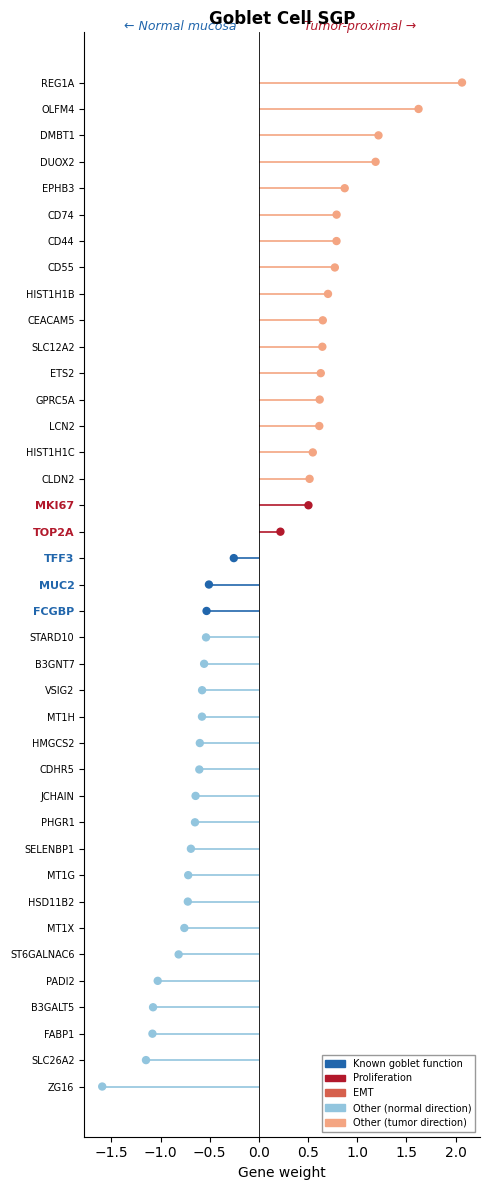

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

gene_weights = pd.Series(-loading_016['Goblet'], index=sdata_crop1['square_016um'].var_names)
# ============================================================
# 参数设置
# ============================================================
top_n = 20  # 每端展示的基因数

# 需要特别标注的已知基因（确保即使不在top_n中也会显示）
known_markers = {
    # goblet功能基因 → 预期蓝色方向
    'MUC2': 'goblet', 'TFF3': 'goblet', 'SPDEF': 'goblet',
    'FCGBP': 'goblet', #'CLCA1': 'goblet',
    # 增殖/EMT基因 → 预期红色方向（请替换为你实际的top正方向基因）
    'MKI67': 'prolif', 'TOP2A': 'prolif', 'PCNA': 'prolif',
    #'VIM': 'emt',
}

# ============================================================
# 选择展示的基因
# ============================================================
sorted_all = gene_weights.sort_values()

# top_neg = sorted_all.head(top_n)
# top_pos = sorted_all.tail(top_n)
# selected = pd.concat([top_neg, top_pos])
top_pos_selected = ['REG1A', 'OLFM4', 'DMBT1', 'DUOX2', 'EPHB3', 'CD74', 'CD44',
           'CD55', 'HIST1H1B', 'CEACAM5', 'SLC12A2', 'ETS2', 'GPRC5A', 
           'LCN2', 'HIST1H1C', 'CLDN2']

# 排成两列
top_neg_selected = ['ZG16', 'SLC26A2','FABP1',
 'B3GALT5',
 'PADI2',
 'ST6GALNAC6',
 'MT1X',
 'HSD11B2',
 'MT1G',
 'SELENBP1',
 'PHGR1',
 'JCHAIN',
 'CDHR5',
 'HMGCS2',
 'MT1H',
 'VSIG2',
 'B3GNT7',
 'STARD10']

selected = pd.concat([gene_weights[top_neg_selected], gene_weights[top_pos_selected]])

# 确保标注基因被包含（即使不在top_n中）
for g in known_markers:
    if g in gene_weights.index and g not in selected.index:
        selected.loc[g] = gene_weights[g]

selected = selected.sort_values()

# ============================================================
# 配色
# ============================================================
color_map = {
    'goblet': '#2166AC',   # 深蓝 - goblet功能基因
    'prolif': '#B2182B',   # 深红 - 增殖
    'emt':    '#D6604D',   # 中红 - EMT
}

def get_color(gene, value):
    if gene in known_markers:
        return color_map[known_markers[gene]]
    return '#92C5DE' if value < 0 else '#F4A582'  # 浅蓝 / 浅红

colors = [get_color(g, v) for g, v in zip(selected.index, selected.values)]

# ============================================================
# Lollipop Plot
# ============================================================
fig, ax = plt.subplots(figsize=(5, 12))
y_pos = np.arange(len(selected))

# 茎 + 点
ax.hlines(y_pos, 0, selected.values, color=colors, linewidth=1.2)
ax.scatter(selected.values, y_pos, color=colors, s=25, zorder=3)

# Y轴基因名
ax.set_yticks(y_pos)
ax.set_yticklabels(selected.index, fontsize=7)

# 加粗 + 变色已知标注基因
for i, label in enumerate(ax.get_yticklabels()):
    gene = selected.index[i]
    if gene in known_markers:
        label.set_fontweight('bold')
        label.set_fontsize(8)
        label.set_color(color_map[known_markers[gene]])

# 零线
ax.axvline(0, color='black', linewidth=0.6)

# 轴标签
ax.set_xlabel('Gene weight', fontsize=10)
ax.set_title('Goblet Cell SGP', fontsize=12, fontweight='bold')

# 去掉上右边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 方向标注
xmin, xmax = selected.min(), selected.max()
ax.text(xmin * 0.5, len(selected) + 1,
        '← Normal mucosa', fontsize=9, color='#2166AC',
        ha='center', fontstyle='italic')
ax.text(xmax * 0.5, len(selected) + 1,
        'Tumor-proximal →', fontsize=9, color='#B2182B',
        ha='center', fontstyle='italic')

# 图例
legend_elements = [
    mpatches.Patch(color='#2166AC', label='Known goblet function'),
    mpatches.Patch(color='#B2182B', label='Proliferation'),
    mpatches.Patch(color='#D6604D', label='EMT'),
    mpatches.Patch(color='#92C5DE', label='Other (normal direction)'),
    mpatches.Patch(color='#F4A582', label='Other (tumor direction)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=7,
          frameon=True, fancybox=False, edgecolor='gray')

plt.tight_layout()
#plt.savefig('goblet_sgp_gene_weights.pdf', dpi=300, bbox_inches='tight')
plt.show()

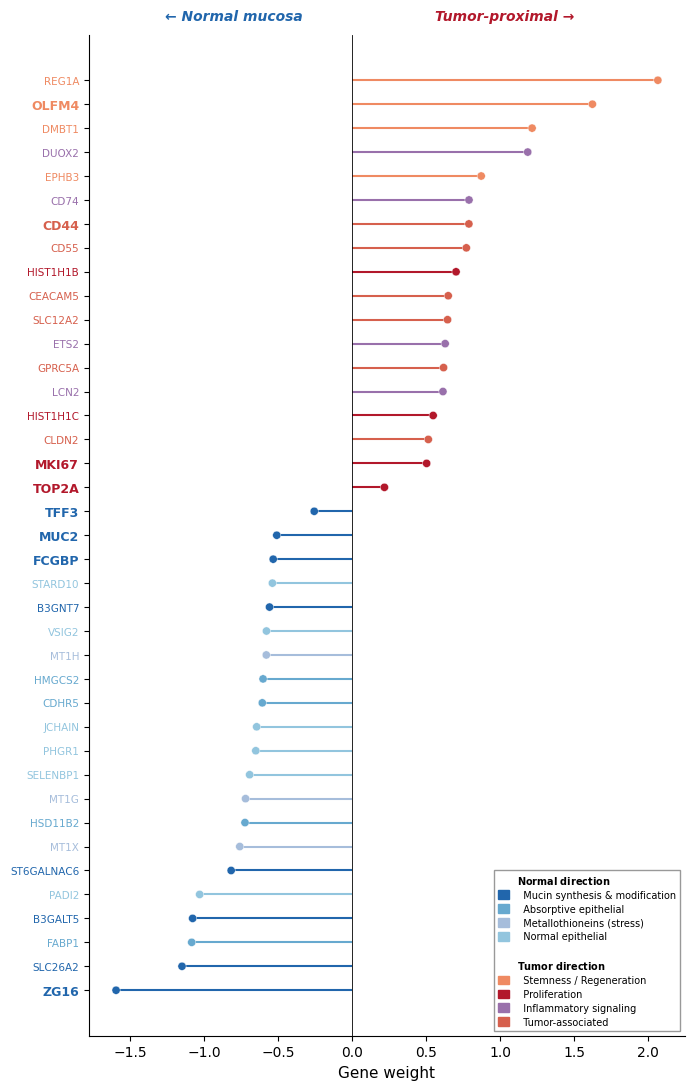

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

gene_weights = pd.Series(-loading_016['Goblet'], index=sdata_crop1['square_016um'].var_names)

# ============================================================
# 功能分类字典
# ============================================================
gene_category = {
    # === Normal mucosa direction (蓝) ===
    # Mucin合成、分泌与修饰
    'MUC2': 'mucin', 'TFF3': 'mucin', 'SPDEF': 'mucin',
    'FCGBP': 'mucin', 'ZG16': 'mucin',
    'B3GALT5': 'mucin', 'ST6GALNAC6': 'mucin',
    'B3GNT7': 'mucin', 'SLC26A2': 'mucin',
    # Absorptive epithelial（enterocyte相关）
    'FABP1': 'absorptive', 'HMGCS2': 'absorptive',
    'CDHR5': 'absorptive', 'HSD11B2': 'absorptive',
    # Metallothioneins（金属稳态/氧化应激）
    'MT1X': 'metal', 'MT1G': 'metal', 'MT1H': 'metal',
    # 其他正常上皮
    'SELENBP1': 'normal_epi', 'PHGR1': 'normal_epi',
    'VSIG2': 'normal_epi', 'PADI2': 'normal_epi',
    'STARD10': 'normal_epi', 'JCHAIN': 'normal_epi',

    # === Tumor-proximal direction (红) ===
    # 干性/再生
    'OLFM4': 'stem', 'EPHB3': 'stem',
    'REG1A': 'stem', 'DMBT1': 'stem',
    # 增殖/细胞周期
    'MKI67': 'prolif', 'TOP2A': 'prolif', 'PCNA': 'prolif',
    'HIST1H1B': 'prolif', 'HIST1H1C': 'prolif',
    # 炎症信号
    'CD74': 'inflam', 'DUOX2': 'inflam',
    'LCN2': 'inflam', 'ETS2': 'inflam',
    # 肿瘤相关（黏附/信号/免疫逃逸）
    'CD44': 'tumor', 'CD55': 'tumor', 'CEACAM5': 'tumor',
    'CLDN2': 'tumor', 'SLC12A2': 'tumor', 'GPRC5A': 'tumor',
}

color_map = {
    'mucin':      '#2166AC',   # 深蓝
    'absorptive': '#67A9CF',   # 中蓝
    'metal':      '#A6BDDB',   # 灰蓝
    'normal_epi': '#92C5DE',   # 浅蓝
    'stem':       '#EF8A62',   # 橙
    'prolif':     '#B2182B',   # 深红
    'inflam':     '#9970AB',   # 紫
    'tumor':      '#D6604D',   # 中红
}

category_labels = {
    'mucin':      'Mucin synthesis & modification',
    'absorptive': 'Absorptive epithelial',
    'metal':      'Metallothioneins (stress)',
    'normal_epi': 'Normal epithelial',
    'stem':       'Stemness / Regeneration',
    'prolif':     'Proliferation',
    'inflam':     'Inflammatory signaling',
    'tumor':      'Tumor-associated',
}

# ============================================================
# 选择展示的基因
# ============================================================
top_pos_selected = ['REG1A', 'OLFM4', 'DMBT1', 'DUOX2', 'EPHB3', 'CD74', 'CD44',
           'CD55', 'HIST1H1B', 'CEACAM5', 'SLC12A2', 'ETS2', 'GPRC5A',
           'LCN2', 'HIST1H1C', 'CLDN2']

top_neg_selected = ['ZG16', 'SLC26A2', 'FABP1', 'B3GALT5', 'PADI2',
    'ST6GALNAC6', 'MT1X', 'HSD11B2', 'MT1G', 'SELENBP1', 'PHGR1',
    'JCHAIN', 'CDHR5', 'HMGCS2', 'MT1H', 'VSIG2', 'B3GNT7', 'STARD10']

selected = pd.concat([gene_weights[top_neg_selected], gene_weights[top_pos_selected]])

known_extra = ['MUC2', 'TFF3', 'SPDEF', 'FCGBP', 'MKI67', 'TOP2A', 'PCNA']
for g in known_extra:
    if g in gene_weights.index and g not in selected.index:
        selected.loc[g] = gene_weights[g]

selected = selected.sort_values()

# ============================================================
# 配色辅助
# ============================================================
def get_color(gene):
    return color_map.get(gene_category.get(gene, ''), '#CCCCCC')

colors = [get_color(g) for g in selected.index]

bold_genes = {'MUC2', 'TFF3', 'SPDEF', 'FCGBP', 'ZG16',
              'MKI67', 'TOP2A', 'PCNA', 'CD44', 'OLFM4'}

# ============================================================
# 画图：左侧 category color bar + 右侧 lollipop
# ============================================================
fig = plt.figure(figsize=(8, 13))
gs = GridSpec(1, 2, width_ratios=[0.03, 1], wspace=0.02)

y_pos = np.arange(len(selected))

# # --- 左侧 annotation bar ---
# ax_bar = fig.add_subplot(gs[0])
# for i, gene in enumerate(selected.index):
#     c = get_color(gene)
#     ax_bar.add_patch(plt.Rectangle((0, i - 0.4), 1, 0.8, color=c, linewidth=0))
# ax_bar.set_xlim(0, 1)
# ax_bar.set_ylim(-0.5, len(selected) - 0.5)
# ax_bar.axis('off')

# --- 右侧 lollipop ---
ax = fig.add_subplot(gs[1])

ax.hlines(y_pos, 0, selected.values, color=colors, linewidth=1.5)
ax.scatter(selected.values, y_pos, color=colors, s=35, zorder=3,
           edgecolors='white', linewidths=0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(selected.index, fontsize=7.5)

for i, label in enumerate(ax.get_yticklabels()):
    gene = selected.index[i]
    label.set_color(get_color(gene))
    if gene in bold_genes:
        label.set_fontweight('bold')
        label.set_fontsize(9)

ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Gene weight', fontsize=11)
#ax.set_title('Goblet Cell SGP — Gene Weight Spectrum', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 方向标注
xmin, xmax = selected.min(), selected.max()
ax.text(xmin * 0.5, len(selected) + 1.5,
        '← Normal mucosa', fontsize=10, color='#2166AC',
        ha='center', fontstyle='italic', fontweight='bold')
ax.text(xmax * 0.5, len(selected) + 1.5,
        'Tumor-proximal →', fontsize=10, color='#B2182B',
        ha='center', fontstyle='italic', fontweight='bold')

# ============================================================
# 分组图例
# ============================================================
legend_normal = ['mucin', 'absorptive', 'metal', 'normal_epi']
legend_tumor  = ['stem', 'prolif', 'inflam', 'tumor']

handles = []
# Normal组标题（用空色块 + 粗体label模拟）
handles.append(mpatches.Patch(color='none', label=r'$\mathbf{Normal\ direction}$'))
for cat in legend_normal:
    handles.append(mpatches.Patch(color=color_map[cat], label=f'  {category_labels[cat]}'))
handles.append(mpatches.Patch(color='none', label=''))  # 空行分隔
handles.append(mpatches.Patch(color='none', label=r'$\mathbf{Tumor\ direction}$'))
for cat in legend_tumor:
    handles.append(mpatches.Patch(color=color_map[cat], label=f'  {category_labels[cat]}'))

ax.legend(handles=handles, loc='lower right', fontsize=7,
          frameon=True, fancybox=False, edgecolor='gray',
          handlelength=1.2, handleheight=1.0, labelspacing=0.4)

plt.tight_layout()
#plt.savefig('goblet_sgp_gene_weights_annotated.pdf', dpi=300, bbox_inches='tight')
plt.show()

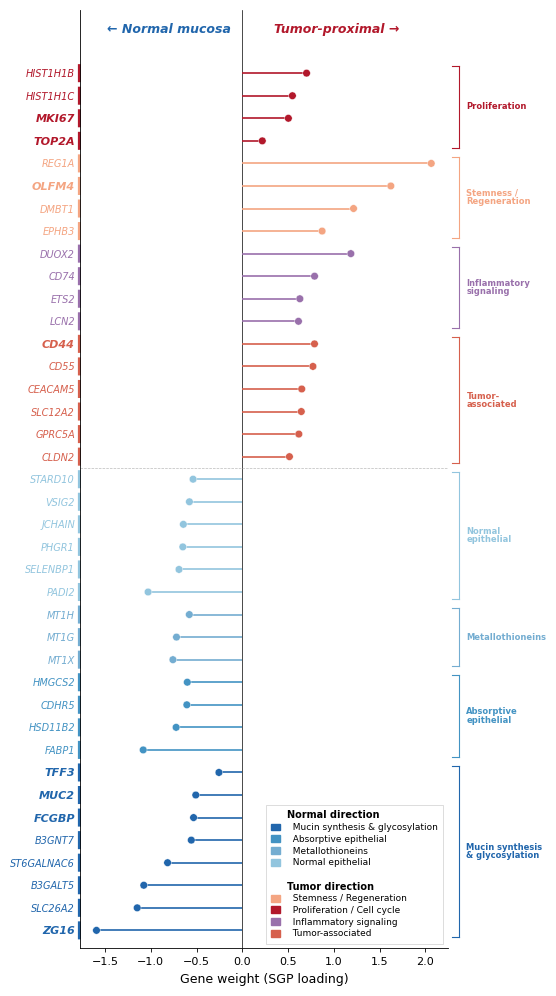

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
from matplotlib.transforms import blended_transform_factory

# ============================================================
# 1. 论文级全局参数
# ============================================================
mpl.rcParams.update({
    #'font.family':       'sans-serif',
    #'font.sans-serif':   ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':         8,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0,
    'xtick.major.size':  3,
    'ytick.major.size':  0,
    'pdf.fonttype':      42,      # TrueType → AI/PDF 可编辑文字
    'ps.fonttype':       42,
})

gene_weights = pd.Series(-loading_016['Goblet'],
                          index=sdata_crop1['square_016um'].var_names)

# ============================================================
# 2. 功能分类 & 色板
# ============================================================
gene_category = {
    # ── Normal mucosa direction ──
    'MUC2': 'mucin', 'TFF3': 'mucin', 'SPDEF': 'mucin',
    'FCGBP': 'mucin', 'ZG16': 'mucin',
    'B3GALT5': 'mucin', 'ST6GALNAC6': 'mucin',
    'B3GNT7': 'mucin', 'SLC26A2': 'mucin',

    'FABP1': 'absorptive', 'HMGCS2': 'absorptive',
    'CDHR5': 'absorptive', 'HSD11B2': 'absorptive',

    'MT1X': 'metal', 'MT1G': 'metal', 'MT1H': 'metal',

    'SELENBP1': 'normal_epi', 'PHGR1': 'normal_epi',
    'VSIG2': 'normal_epi', 'PADI2': 'normal_epi',
    'STARD10': 'normal_epi', 'JCHAIN': 'normal_epi',

    # ── Tumor-proximal direction ──
    'OLFM4': 'stem', 'EPHB3': 'stem',
    'REG1A': 'stem', 'DMBT1': 'stem',

    'MKI67': 'prolif', 'TOP2A': 'prolif', 'PCNA': 'prolif',
    'HIST1H1B': 'prolif', 'HIST1H1C': 'prolif',

    'CD74': 'inflam', 'DUOX2': 'inflam',
    'LCN2': 'inflam', 'ETS2': 'inflam',

    'CD44': 'tumor', 'CD55': 'tumor', 'CEACAM5': 'tumor',
    'CLDN2': 'tumor', 'SLC12A2': 'tumor', 'GPRC5A': 'tumor',
}

color_map = {
    'mucin':      '#2166AC',
    'absorptive': '#4393C3',
    'metal':      '#74ADD1',
    'normal_epi': '#92C5DE',
    'stem':       '#F4A582',
    'prolif':     '#B2182B',
    'inflam':     '#9970AB',
    'tumor':      '#D6604D',
}

# 右侧 bracket 简短标签
bracket_labels = {
    'mucin':      'Mucin synthesis\n& glycosylation',
    'absorptive': 'Absorptive\nepithelial',
    'metal':      'Metallothioneins',
    'normal_epi': 'Normal\nepithelial',
    'stem':       'Stemness /\nRegeneration',
    'prolif':     'Proliferation',
    'inflam':     'Inflammatory\nsignaling',
    'tumor':      'Tumor-\nassociated',
}

# 图例长标签
legend_labels = {
    'mucin':      'Mucin synthesis & glycosylation',
    'absorptive': 'Absorptive epithelial',
    'metal':      'Metallothioneins',
    'normal_epi': 'Normal epithelial',
    'stem':       'Stemness / Regeneration',
    'prolif':     'Proliferation / Cell cycle',
    'inflam':     'Inflammatory signaling',
    'tumor':      'Tumor-associated',
}

# ============================================================
# 3. 选择展示基因
# ============================================================
top_pos_selected = [
    'REG1A', 'OLFM4', 'DMBT1', 'DUOX2', 'EPHB3', 'CD74', 'CD44',
    'CD55', 'HIST1H1B', 'CEACAM5', 'SLC12A2', 'ETS2', 'GPRC5A',
    'LCN2', 'HIST1H1C', 'CLDN2']

top_neg_selected = [
    'ZG16', 'SLC26A2', 'FABP1', 'B3GALT5', 'PADI2',
    'ST6GALNAC6', 'MT1X', 'HSD11B2', 'MT1G', 'SELENBP1', 'PHGR1',
    'JCHAIN', 'CDHR5', 'HMGCS2', 'MT1H', 'VSIG2', 'B3GNT7', 'STARD10']

selected = pd.concat([gene_weights[top_neg_selected],
                       gene_weights[top_pos_selected]])

known_extra = ['MUC2', 'TFF3', 'SPDEF', 'FCGBP', 'MKI67', 'TOP2A', 'PCNA']
for g in known_extra:
    if g in gene_weights.index and g not in selected.index:
        selected.loc[g] = gene_weights[g]

# ============================================================
# 4. 三级排序：方向 → 功能类别 → 权重
#    使同一功能的基因聚在一起，方便 bracket 标注
# ============================================================
cat_rank_neg = {'mucin': 0, 'absorptive': 1, 'metal': 2, 'normal_epi': 3}
cat_rank_pos = {'tumor': 0, 'inflam': 1, 'stem': 2, 'prolif': 3}

sort_df = pd.DataFrame({
    'weight': selected,
    'cat':    [gene_category.get(g, 'unknown') for g in selected.index],
})
sort_df['direction'] = (sort_df['weight'] >= 0).astype(int)
sort_df['cat_rank']  = sort_df.apply(
    lambda r: cat_rank_neg.get(r['cat'], 99) if r['direction'] == 0
              else cat_rank_pos.get(r['cat'], 99), axis=1)
sort_df = sort_df.sort_values(['direction', 'cat_rank', 'weight'])
selected = selected[sort_df.index]

# ============================================================
# 5. 检测连续同类别块（bracket 标注用）
# ============================================================
cat_list = [gene_category.get(g, 'unknown') for g in selected.index]
blocks = []
i = 0
while i < len(cat_list):
    cat = cat_list[i]
    j = i + 1
    while j < len(cat_list) and cat_list[j] == cat:
        j += 1
    if cat != 'unknown':
        blocks.append((cat, i, j - 1))
    i = j

# ============================================================
# 6. 辅助
# ============================================================
def get_color(gene):
    return color_map.get(gene_category.get(gene, ''), '#AAAAAA')

colors = [get_color(g) for g in selected.index]

highlight_genes = {'MUC2', 'TFF3', 'SPDEF', 'FCGBP', 'ZG16',
                   'MKI67', 'TOP2A', 'PCNA', 'CD44', 'OLFM4'}

# ============================================================
# 7. 绘图
# ============================================================
fig, ax = plt.subplots(figsize=(6, 10))
y_pos = np.arange(len(selected))

# ---- 左侧 annotation color bar ----
trans_left = blended_transform_factory(ax.transAxes, ax.transData)
bar_x, bar_w = -0.005, 0.008          # axes 坐标
for i, gene in enumerate(selected.index):
    ax.add_patch(mpatches.FancyBboxPatch(
        (bar_x, i - 0.4), bar_w, 0.8,
        boxstyle='round,pad=0',
        facecolor=get_color(gene), edgecolor='none',
        transform=trans_left, clip_on=False))

# ---- 棒棒糖：茎线 + 圆点 ----
ax.hlines(y_pos, 0, selected.values,
          color=colors, linewidth=1.2, zorder=2)
ax.scatter(selected.values, y_pos, color=colors, s=30, zorder=3,
           edgecolors='white', linewidths=0.3)

# ---- Y 轴基因名（斜体 = 生物学规范）----
ax.set_yticks(y_pos)
ax.set_yticklabels(selected.index, fontsize=7)

for i, label in enumerate(ax.get_yticklabels()):
    gene = selected.index[i]
    label.set_fontstyle('italic')          # 基因名斜体
    label.set_color(get_color(gene))
    if gene in highlight_genes:
        label.set_fontweight('bold')
        label.set_fontsize(8)

# ---- 零线 + 方向分界虚线 ----
ax.axvline(0, color='k', linewidth=0.5, zorder=1)

n_neg = sum(1 for v in selected.values if v < 0)
if 0 < n_neg < len(selected):
    ax.axhline(n_neg - 0.5, color='#BBBBBB', linewidth=0.5,
               linestyle='--', zorder=1)

# ---- 轴格式 ----
ax.set_xlabel('Gene weight (SGP loading)', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', labelsize=8, direction='out')
ax.set_ylim(-0.8, len(selected) + 1.8)

# ---- 右侧 bracket 功能标注 ----
trans_right = blended_transform_factory(ax.transAxes, ax.transData)

for cat, idx_start, idx_end in blocks:
    y0   = idx_start - 0.3
    y1   = idx_end   + 0.3
    ymid = (idx_start + idx_end) / 2
    c    = color_map[cat]

    # "]" 形 bracket
    ax.plot([1.01, 1.03], [y0, y0], color=c, lw=0.8,
            clip_on=False, transform=trans_right)
    ax.plot([1.01, 1.03], [y1, y1], color=c, lw=0.8,
            clip_on=False, transform=trans_right)
    ax.plot([1.03, 1.03], [y0, y1], color=c, lw=0.8,
            clip_on=False, transform=trans_right)

    ax.text(1.05, ymid, bracket_labels[cat],
            fontsize=6, color=c, va='center', ha='left',
            fontweight='semibold', clip_on=False,
            transform=trans_right, linespacing=0.9)

# ---- 方向标注 ----
xmin_val, xmax_val = selected.min(), selected.max()
ax.text(xmin_val * 0.5, len(selected) + 0.8,
        '← Normal mucosa', fontsize=9, color='#2166AC',
        ha='center', fontstyle='italic', fontweight='bold')
ax.text(xmax_val * 0.5, len(selected) + 0.8,
        'Tumor-proximal →', fontsize=9, color='#B2182B',
        ha='center', fontstyle='italic', fontweight='bold')

# ============================================================
# 8. 分组图例
# ============================================================
neg_cats = ['mucin', 'absorptive', 'metal', 'normal_epi']
pos_cats = ['stem', 'prolif', 'inflam', 'tumor']

handles = []
handles.append(mpatches.Patch(color='none', label='Normal direction'))
for cat in neg_cats:
    handles.append(mpatches.Patch(
        color=color_map[cat], label=f'  {legend_labels[cat]}'))
handles.append(mpatches.Patch(color='none', label=''))     # 空行分隔
handles.append(mpatches.Patch(color='none', label='Tumor direction'))
for cat in pos_cats:
    handles.append(mpatches.Patch(
        color=color_map[cat], label=f'  {legend_labels[cat]}'))

leg = ax.legend(handles=handles, loc='lower right', fontsize=6.5,
                frameon=True, fancybox=False, edgecolor='#CCCCCC',
                handlelength=1.0, handleheight=0.8, labelspacing=0.3,
                borderpad=0.6)
leg.get_frame().set_linewidth(0.5)
leg.get_frame().set_alpha(0.95)

for text in leg.get_texts():
    if text.get_text() in ('Normal direction', 'Tumor direction'):
        text.set_fontweight('bold')
        text.set_fontsize(7)

# ============================================================
# 9. 布局 & 输出
# ============================================================
fig.tight_layout()
fig.subplots_adjust(right=0.75)        # 为右侧 bracket 留白

#plt.savefig('goblet_sgp_gene_weights.pdf',
#           dpi=300, bbox_inches='tight', transparent=True)
#plt.savefig('goblet_sgp_gene_weights.png',
#            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [7]:
loading_016.to_csv('loading_016.csv')

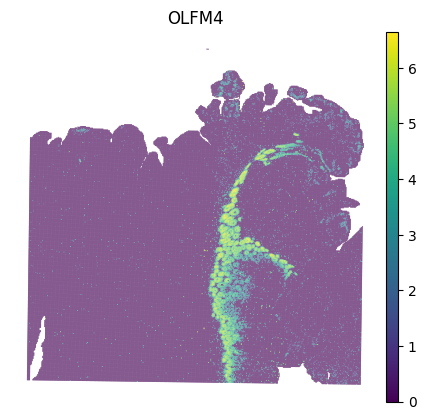

In [12]:
sc.pl.spatial(sdata_crop1['square_016um'], color = 'OLFM4',
              spot_size=60, img_key=None, frameon=False, title='OLFM4',
              #save=os.path.join('CRC_008_celltype.pdf')
              ) 

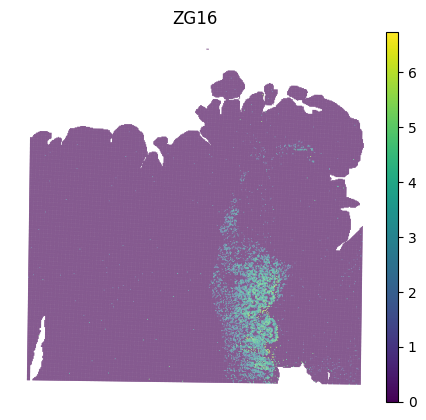

In [13]:
sc.pl.spatial(sdata_crop1['square_016um'], color = 'ZG16',
              spot_size=60, img_key=None, frameon=False, title='ZG16',
              #save=os.path.join('CRC_008_celltype.pdf')
              ) 

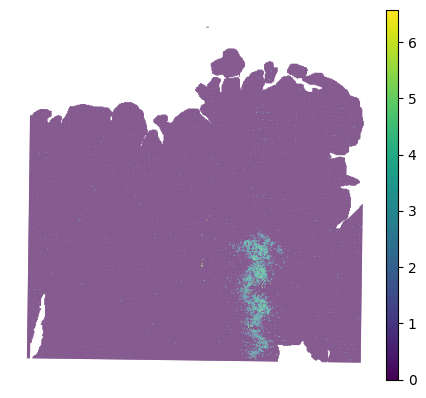

In [44]:
sc.pl.spatial(sdata_crop1['square_016um'], color = 'CA1',
              spot_size=60, img_key=None, frameon=False, title='',
              #save=os.path.join('CRC_008_celltype.pdf')
              ) 

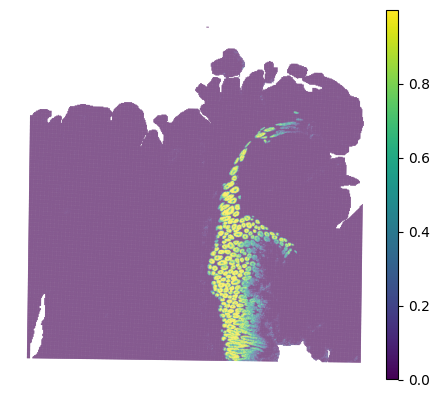

In [11]:
sc.pl.spatial(sdata_crop1['square_016um'], color = 'Goblet',
              spot_size=60, img_key=None, frameon=False, title='',
              #save=os.path.join('CRC_008_celltype.pdf')
              ) 

In [180]:
RAW_PATH = "/import/home2/share/yqzeng/data/CRC"
DATA_PATH = "/import/home2/share/yqzeng/MacSGP/data/CRC"
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/results/CRC" 

sample_size = 50000
save_path = os.path.join(SAVE_PATH, f"{sample_size}_spots", 'spicemix')
file_path = os.path.join(save_path, 'files')
os.makedirs(save_path, exist_ok=True)
os.makedirs(file_path, exist_ok=True)

In [181]:
factors = pd.read_csv(os.path.join(save_path, 'factors.csv'), index_col=0)
loadings = pd.read_csv(os.path.join(save_path, 'loadings.csv'), index_col=0)
coordinates = pd.read_csv(os.path.join(save_path, 'coordinates.csv'), index_col=0)

In [182]:
sdata_crop1_subsample = sdata_crop1['square_016um'][coordinates.index]

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   


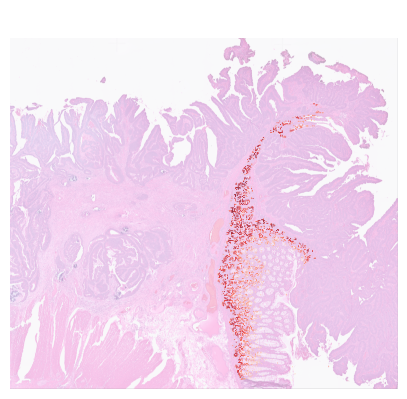

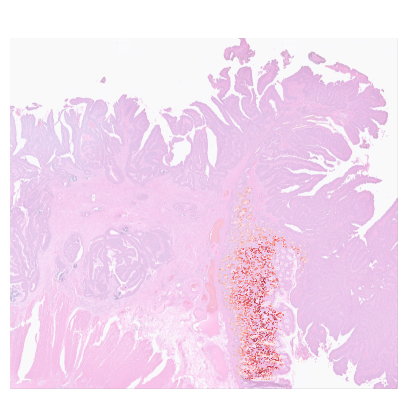

In [183]:
proportion_threshold = 0.1
# norm = TwoSlopeNorm(vcenter=0)
# ct_plot = ["Tumor III", "CAF", "Goblet", "Macrophage"]
# reverse_list = [False, True, True, False]
factor_list = ["Factor_3", "Factor_18"]
program_cmap=plt.get_cmap('Reds')
colors=program_cmap(np.arange(program_cmap.N))
colors[0:program_cmap.N//10,3] = 0
program_cmap = ListedColormap(colors)
ct = 'Goblet'

for factor in factor_list:
        axes = plt.subplots(1,1, figsize=(5, 5), dpi=100)[1]
        # axes off
        axes.set_axis_off()

        sdata_crop1_subsample.obs['tmp'] = factors[factor]
        # if reverse_list[ct_plot.index(ct)]:
        #     sdata_crop1_subsample.obs['tmp'] = -sdata_crop1_subsample.obs['tmp']
        filter = sdata_crop1_subsample.obsm['proportion'][ct]>=proportion_threshold
        if filter.sum() == 0:
                print(f"No spots meet the proportion threshold for cell type {ct}.")
        sdata_crop1_subsample.obs['tmp'] = sdata_crop1_subsample.obs['tmp'].where(filter, 0)
        sdata_crop1['square_016um'].obs['tmp'] = 0
        sdata_crop1['square_016um'].obs['tmp'][coordinates.index] = sdata_crop1_subsample.obs['tmp']
        #
        plot = sdata_crop1.pl.render_images('Visium_HD_Human_Colon_Cancer_P2_hires_image', alpha=0.35, scale='scale4').pl.render_shapes(
                "Visium_HD_Human_Colon_Cancer_P2_square_016um", 
                color="tmp",# method='datashader',
                table_name='square_016um',
                datashader_reduction='mean',
                cmap=program_cmap,
                #norm=norm,
                method='matplotlib',
        ).pl.show(title='', 
                coordinate_systems="global", ax=axes, dpi=100, frameon=None,
                #save='CRC_016_{}.pdf'.format(ct), 
                colorbar=False)

In [184]:
save_path = os.path.join(SAVE_PATH, f"{sample_size}_spots", 'mofa')

factors = pd.read_csv(os.path.join(save_path, 'factors.csv'), index_col=0)
loadings = pd.read_csv(os.path.join(save_path, 'loadings.csv'), index_col=0)

sdata_crop1_subsample = sdata_crop1['square_016um'][factors.index]

INFO     Rasterizing image for faster rendering.                                                                   


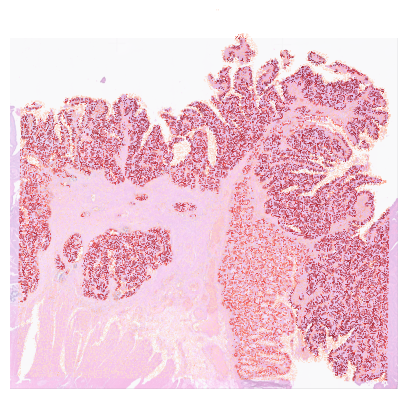

In [185]:
proportion_threshold = 0.1
# norm = TwoSlopeNorm(vcenter=0)
# ct_plot = ["Tumor III", "CAF", "Goblet", "Macrophage"]
# reverse_list = [False, True, True, False]
factor_list = ["Factor1"]
program_cmap=plt.get_cmap('Reds')
colors=program_cmap(np.arange(program_cmap.N))
colors[0:program_cmap.N//10,3] = 0
program_cmap = ListedColormap(colors)
ct = 'Goblet'

for factor in factor_list:
        axes = plt.subplots(1,1, figsize=(5, 5), dpi=100)[1]
        # axes off
        axes.set_axis_off()

        sdata_crop1_subsample.obs['tmp'] = factors[factor]
        # normalize the factor values to [0, 1]
        sdata_crop1_subsample.obs['tmp'] = (sdata_crop1_subsample.obs['tmp'] - sdata_crop1_subsample.obs['tmp'].min()) / (sdata_crop1_subsample.obs['tmp'].max() - sdata_crop1_subsample.obs['tmp'].min())
        # if reverse_list[ct_plot.index(ct)]:
        #     sdata_crop1_subsample.obs['tmp'] = -sdata_crop1_subsample.obs['tmp']
        # filter = sdata_crop1_subsample.obsm['proportion'][ct]>=proportion_threshold
        # if filter.sum() == 0:
        #         print(f"No spots meet the proportion threshold for cell type {ct}.")
        # sdata_crop1_subsample.obs['tmp'] = sdata_crop1_subsample.obs['tmp'].where(filter, 0)
        sdata_crop1['square_016um'].obs['tmp'] = 0
        sdata_crop1['square_016um'].obs['tmp'][factors.index] = sdata_crop1_subsample.obs['tmp']
        #
        plot = sdata_crop1.pl.render_images('Visium_HD_Human_Colon_Cancer_P2_hires_image', alpha=0.35, scale='scale4').pl.render_shapes(
                "Visium_HD_Human_Colon_Cancer_P2_square_016um", 
                color="tmp",# method='datashader',
                table_name='square_016um',
                datashader_reduction='mean',
                cmap=program_cmap,
                #norm=norm,
                method='matplotlib',
        ).pl.show(title='', 
                coordinate_systems="global", ax=axes, dpi=100, frameon=None,
                #save='CRC_016_{}.pdf'.format(ct), 
                colorbar=False)

In [17]:
program_cmap=plt.get_cmap('Reds')
colors=program_cmap(np.arange(program_cmap.N))
colors[0:program_cmap.N//10,3] = 0
program_cmap = ListedColormap(colors)

INFO     Rasterizing image for faster rendering.                                                                   


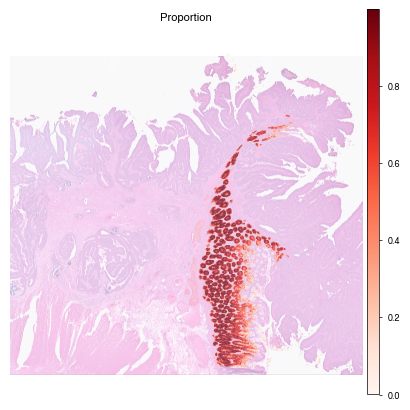

In [18]:
ct = 'Goblet'
axes = plt.subplots(1,1, figsize=(5, 5), dpi=100)[1]
# axes off
axes.set_axis_off()
sdata_crop1.pl.render_images('Visium_HD_Human_Colon_Cancer_P2_hires_image', alpha=0.35, scale='scale4').pl.render_shapes(
        "Visium_HD_Human_Colon_Cancer_P2_square_016um", 
        color=ct,# method='datashader',
        table_name='square_016um',
        datashader_reduction='mean',
        cmap=program_cmap,
        method='matplotlib',
).pl.show(title='Proportion', 
          coordinate_systems="global", ax=axes, dpi=100, frameon=None,
          #save=f'proportion_{ct}',
          colorbar=True,
          )


In [6]:
mpl.rcParams.update({
    'font.family': 'Helvetica',  # 使用 Helvetica 字体
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,       # 嵌入字体，便于编辑
    'ps.fonttype': 42,
    'savefig.dpi': 600,
    'figure.dpi': 300,
})

In [23]:
loading_xenium_ct = adata_xenium.varm['loading']['Goblet']

In [25]:
loading_xenium_ct.nlargest(20)

CHGA     1.849911
CHGB     1.706220
REG1A    1.341222
REG3A    1.226038
INSM1    1.199007
SCGN     1.106834
GCG      1.058221
LGR5     1.042338
SCG5     1.001747
CPE      0.977644
DUOX2    0.946660
CES1     0.928184
SMOC2    0.869896
CDCA7    0.838537
DMBT1    0.833419
SCG2     0.829108
EPHB3    0.824732
MS4A8    0.802792
OLFM4    0.690924
TGFBI    0.655466
Name: Goblet, dtype: float32

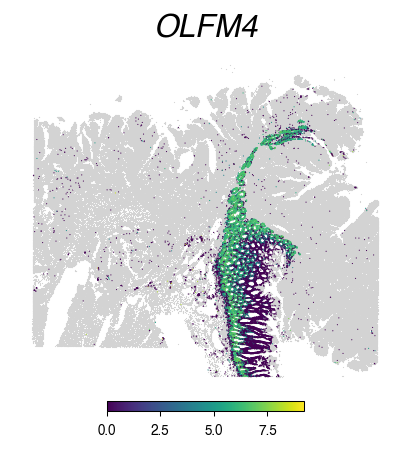

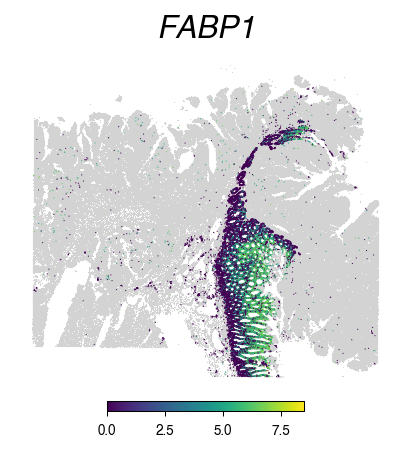

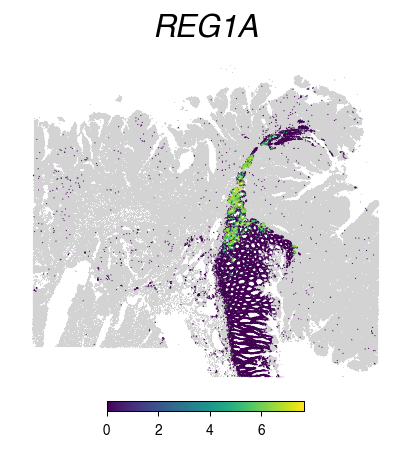

In [26]:
import scanpy as sc
adata_xenium = sc.read_h5ad(os.path.join("/home/yzengbj/my_project/results/CRC", "adata_xenium_filtered_10_18.h5ad"))
gene_list = ['OLFM4', 'FABP1', 'REG1A']

mask = adata_xenium.obsm['proportion']['Goblet'] > 0.1
for gene in gene_list:
    data = adata_xenium[:, gene].X.toarray()
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    background = ax.scatter(
        -adata_xenium.obsm['spatial'][:, 0],
        -adata_xenium.obsm['spatial'][:, 1],
        c='lightgray',
        s=0.3,
        linewidths=0
    )
    sc1 = ax.scatter(
        -adata_xenium.obsm['spatial'][mask, 0],
        -adata_xenium.obsm['spatial'][mask, 1],
        c=data[mask],
        s=0.3,
        cmap='viridis',
        linewidths=0
    )

    cb   = fig.colorbar(sc1, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')

    #cb.set_label('Expression', fontsize=12)

    #cb.set_ticks([])
    # 去掉边框
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)

    ax.set_title(gene, fontsize=15, fontstyle='italic')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

In [8]:
sdata_crop1['square_016um']

AnnData object with n_obs × n_vars = 137051 × 2780
    obs: 'in_tissue', 'array_row', 'array_col', 'library_size', 'alpha', 'CAF', 'CD8_T_cell', 'Endothelial', 'Enteric_Glial', 'Enterocyte', 'Fibroblast', 'Goblet', 'Lymphatic_Endothelial', 'Macrophage', 'Myofibroblast', 'Neutrophil', 'Pericytes', 'Plasma', 'Proliferating_Fibroblast', 'Proliferating_Immune_II', 'Proliferating_Macrophages', 'Tuft', 'Tumor_III', 'Tumor_V', 'cDC_I', 'mRegDC', 'vSM', 'program_CAF', 'program_CD8_T_cell', 'program_Endothelial', 'program_Enteric_Glial', 'program_Enterocyte', 'program_Fibroblast', 'program_Goblet', 'program_Lymphatic_Endothelial', 'program_Macrophage', 'program_Myofibroblast', 'program_Neutrophil', 'program_Pericytes', 'program_Plasma', 'program_Proliferating_Fibroblast', 'program_Proliferating_Immune_II', 'program_Proliferating_Macrophages', 'program_Tuft', 'program_Tumor_III', 'program_Tumor_V', 'program_cDC_I', 'program_mRegDC', 'program_vSM', 'location_id', 'region'
    var: 'gene_ids', 'fe

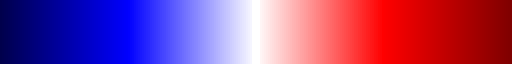

In [114]:
program_cmap=plt.get_cmap('seismic')
colors=program_cmap(np.arange(program_cmap.N))
colors[program_cmap.N//2-2:program_cmap.N//2+2,3] = 0
program_cmap = ListedColormap(colors)
norm = TwoSlopeNorm(vcenter=0)
program_cmap

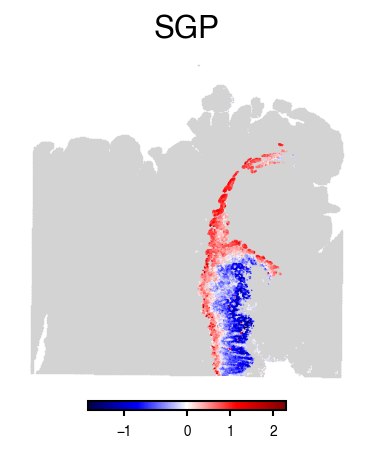

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Goblet'
data = -sdata_crop1['square_016um'].obsm['factor'][ct]
prop = sdata_crop1['square_016um'].obsm['proportion'][ct]
fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
#two slope norm
norm = TwoSlopeNorm(vcenter=0)
mask = prop < 0.1
sc_ignore = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][mask, 1],
    c='lightgray',
    s=0.5,
    linewidths=0,
    #norm=norm
)
sc = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][~mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][~mask, 1],
    c=data[~mask],
    s=0.5,
    cmap=program_cmap,
    linewidths=0,
    norm=norm
)
# cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
# cb.locator = MaxNLocator(nbins=5)
# cb.update_ticks()
# cb.ax.tick_params(labelsize=12)
# #cb.set_label('Proportion', fontsize=12)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
#cb.set_label('Normalized score', fontsize=12)
# no ticks
#cb.set_ticks([])
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('SGP', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

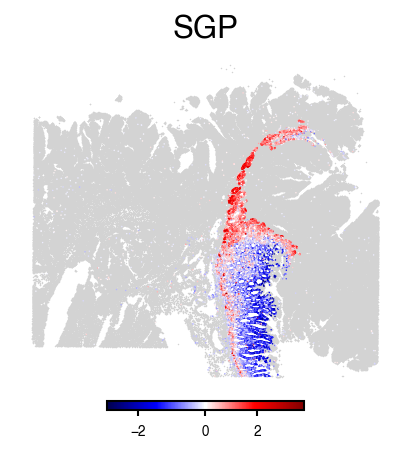

In [126]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Goblet'
data = adata_xenium.obsm['factor'][ct]
prop = adata_xenium.obsm['proportion'][ct]
fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
#two slope norm
norm = TwoSlopeNorm(vcenter=0)
mask = prop < 0.1
sc_ignore = ax.scatter(
    -adata_xenium.obsm['spatial'][mask, 0],
    -adata_xenium.obsm['spatial'][mask, 1],
    c='lightgray',
    s=0.5,
    linewidths=0,
    #norm=norm
)
sc = ax.scatter(
    -adata_xenium.obsm['spatial'][~mask, 0],
    -adata_xenium.obsm['spatial'][~mask, 1],
    c=data[~mask],
    s=0.5,
    cmap=program_cmap,
    linewidths=0,
    norm=norm
)
# cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
# cb.locator = MaxNLocator(nbins=5)
# cb.update_ticks()
# cb.ax.tick_params(labelsize=12)
# #cb.set_label('Proportion', fontsize=12)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
#cb.set_label('Normalized score', fontsize=12)
# no ticks
#cb.set_ticks([])
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('SGP', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

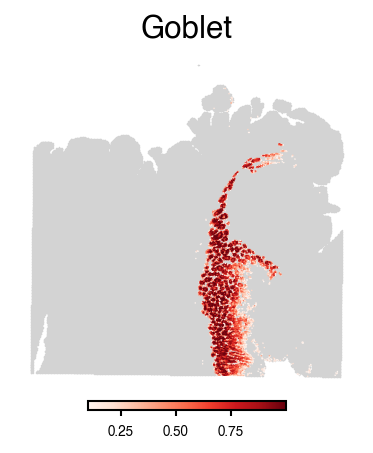

In [120]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Goblet'
data = sdata_crop1['square_016um'].obsm['proportion'][ct]
prop = sdata_crop1['square_016um'].obsm['proportion'][ct]
fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
#two slope norm
norm = TwoSlopeNorm(vcenter=0)
mask = prop < 0.1
sc_ignore = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][mask, 1],
    c='lightgray',
    s=0.5,
    linewidths=0,
    #norm=norm
)
sc = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][~mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][~mask, 1],
    c=data[~mask],
    s=0.5,
    cmap='Reds',
    linewidths=0,
    #norm=norm
)
# cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
# cb.locator = MaxNLocator(nbins=5)
# cb.update_ticks()
# cb.ax.tick_params(labelsize=12)
# #cb.set_label('Proportion', fontsize=12)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
#cb.set_label('Normalized score', fontsize=12)
# no ticks
#cb.set_ticks([])
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('Goblet', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

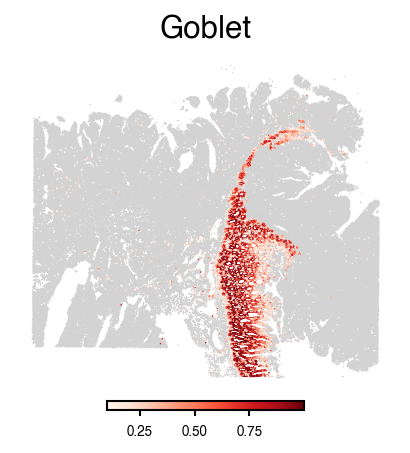

In [129]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Goblet'
data = adata_xenium.obsm['proportion'][ct]
prop = adata_xenium.obsm['proportion'][ct]
fig, ax = plt.subplots(figsize=(3.5, 3.2))
norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
#two slope norm
norm = TwoSlopeNorm(vcenter=0)
mask = prop < 0.1
sc_ignore = ax.scatter(
    -adata_xenium.obsm['spatial'][mask, 0],
    -adata_xenium.obsm['spatial'][mask, 1],
    c='lightgray',
    s=0.5,
    linewidths=0,
    #norm=norm
)
sc = ax.scatter(
    -adata_xenium.obsm['spatial'][~mask, 0],
    -adata_xenium.obsm['spatial'][~mask, 1],
    c=data[~mask],
    s=0.5,
    cmap='Reds',
    linewidths=0,
    #norm=norm
)
# cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
# cb.locator = MaxNLocator(nbins=5)
# cb.update_ticks()
# cb.ax.tick_params(labelsize=12)
# #cb.set_label('Proportion', fontsize=12)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
#cb.set_label('Normalized score', fontsize=12)
# no ticks
#cb.set_ticks([])
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('Goblet', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

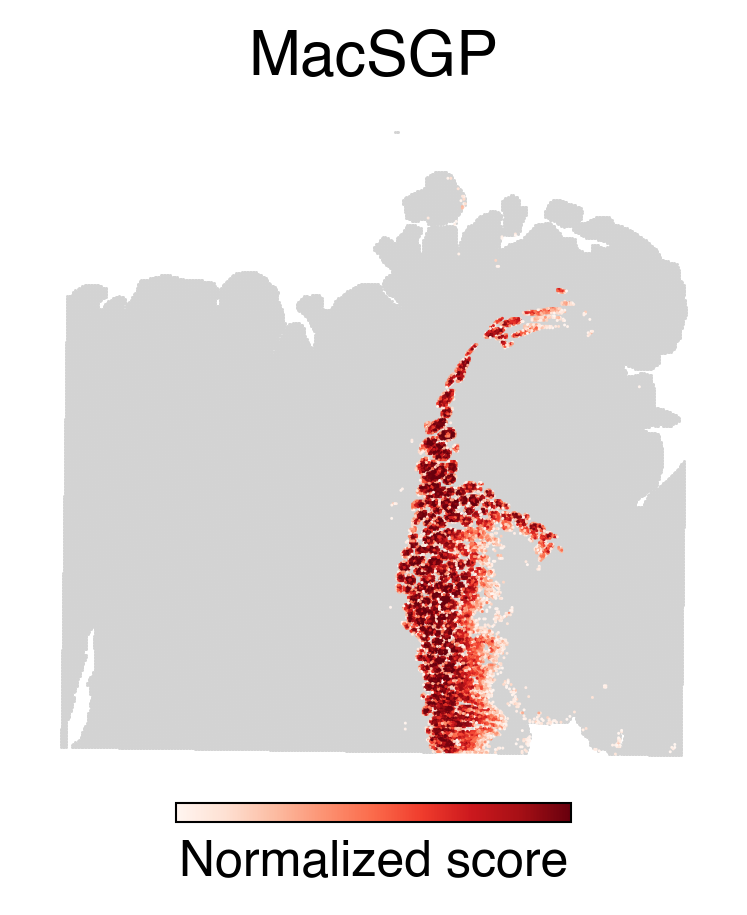

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

ct = 'Goblet'
data = sdata_crop1['square_016um'].obsm['proportion'][ct]
prop = sdata_crop1['square_016um'].obsm['proportion'][ct]
fig, ax = plt.subplots(figsize=(3.5, 3.2))
#norm = mpl.colors.Normalize(vmin=-0.8, vmax=0.8)
#two slope norm
norm = TwoSlopeNorm(vcenter=0)
mask = prop < 0.1
sc_ignore = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][mask, 1],
    c='lightgray',
    s=0.5,
    linewidths=0,
    #norm=norm
)
sc = ax.scatter(
    sdata_crop1['square_016um'].obsm['spatial'][~mask, 0],
    -sdata_crop1['square_016um'].obsm['spatial'][~mask, 1],
    c=data[~mask],
    s=0.5,
    cmap='Reds',
    linewidths=0,
    #norm=norm
)
# cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
# cb.locator = MaxNLocator(nbins=5)
# cb.update_ticks()
# cb.ax.tick_params(labelsize=12)
# #cb.set_label('Proportion', fontsize=12)
cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')
#cb.locator = MaxNLocator(nbins=1)
#cb.update_ticks()
#cb.ax.tick_params(labelsize=0)
cb.set_label('Normalized score', fontsize=12)
# no ticks
cb.set_ticks([])
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title('MacSGP', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

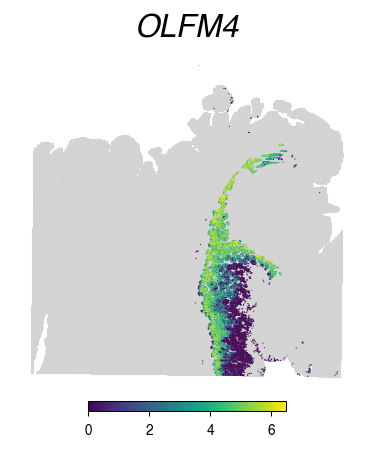

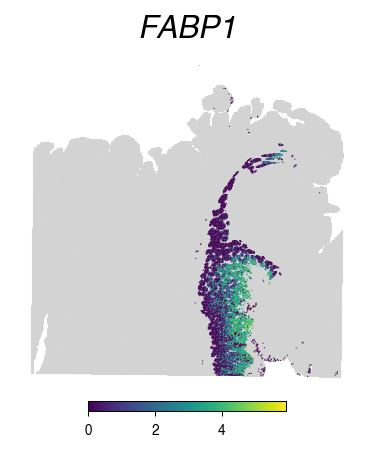

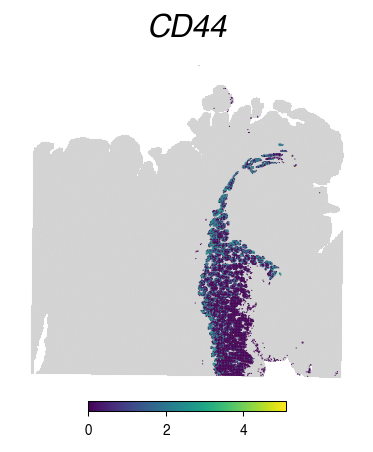

In [20]:

gene_list = ['OLFM4', 'FABP1', "CD44"]

mask = sdata_crop1['square_016um'].obsm['proportion']['Goblet'] > 0.1
for gene in gene_list:
    data = sdata_crop1['square_016um'][:, gene].X.toarray()
    fig, ax = plt.subplots(figsize=(3.5, 3.2))
    background = ax.scatter(
        sdata_crop1['square_016um'].obsm['spatial'][:, 0],
        -sdata_crop1['square_016um'].obsm['spatial'][:, 1],
        c='lightgray',
        s=0.3,
        linewidths=0
    )
    sc = ax.scatter(
        sdata_crop1['square_016um'].obsm['spatial'][mask, 0],
        -sdata_crop1['square_016um'].obsm['spatial'][mask, 1],
        c=data[mask],
        s=0.3,
        cmap='viridis',
        linewidths=0
    )

    cb   = fig.colorbar(sc, ax=ax, shrink=0.4, pad=0.02, orientation='horizontal')

    #cb.set_label('Expression', fontsize=12)

    #cb.set_ticks([])
    # 去掉边框
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)

    ax.set_title(gene, fontsize=15, fontstyle='italic')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
adata = sdata_crop1['square_016um']
# %% 1. 提取空间坐标和细胞类型
spatial = adata.obsm['spatial']  # (n_cells, 2)，根据你的数据改 key
cell_types = adata.obs['cell_type']  # 根据你的列名改

print(cell_types.value_counts())  # 先看看有哪些类型、叫什么名字

# %% 2. 找到 goblet 和 tumor 细胞的 index
goblet_mask = cell_types == 'Goblet'       # 根据实际名字改
tumor_mask = (cell_types == 'Tumor III')   # 根据实际名字改

goblet_coords = spatial[goblet_mask]       # (n_goblet, 2)
tumor_coords = spatial[tumor_mask]         # (n_tumor, 2)

KeyError: 'cell_type'

In [34]:
dist_matrix = cdist(goblet_coords, tumor_coords, metric='euclidean')  # (n_goblet, n_tumor)
min_dist_to_tumor = dist_matrix.min(axis=1)  # (n_goblet,)

print(f"Distance range: {min_dist_to_tumor.min():.1f} ~ {min_dist_to_tumor.max():.1f}")

Distance range: 58.4 ~ 2755.3


In [7]:
factor_scores_goblet = adata.obsm['factor'][goblet_mask]  # (n_goblet, K)

NameError: name 'goblet_mask' is not defined

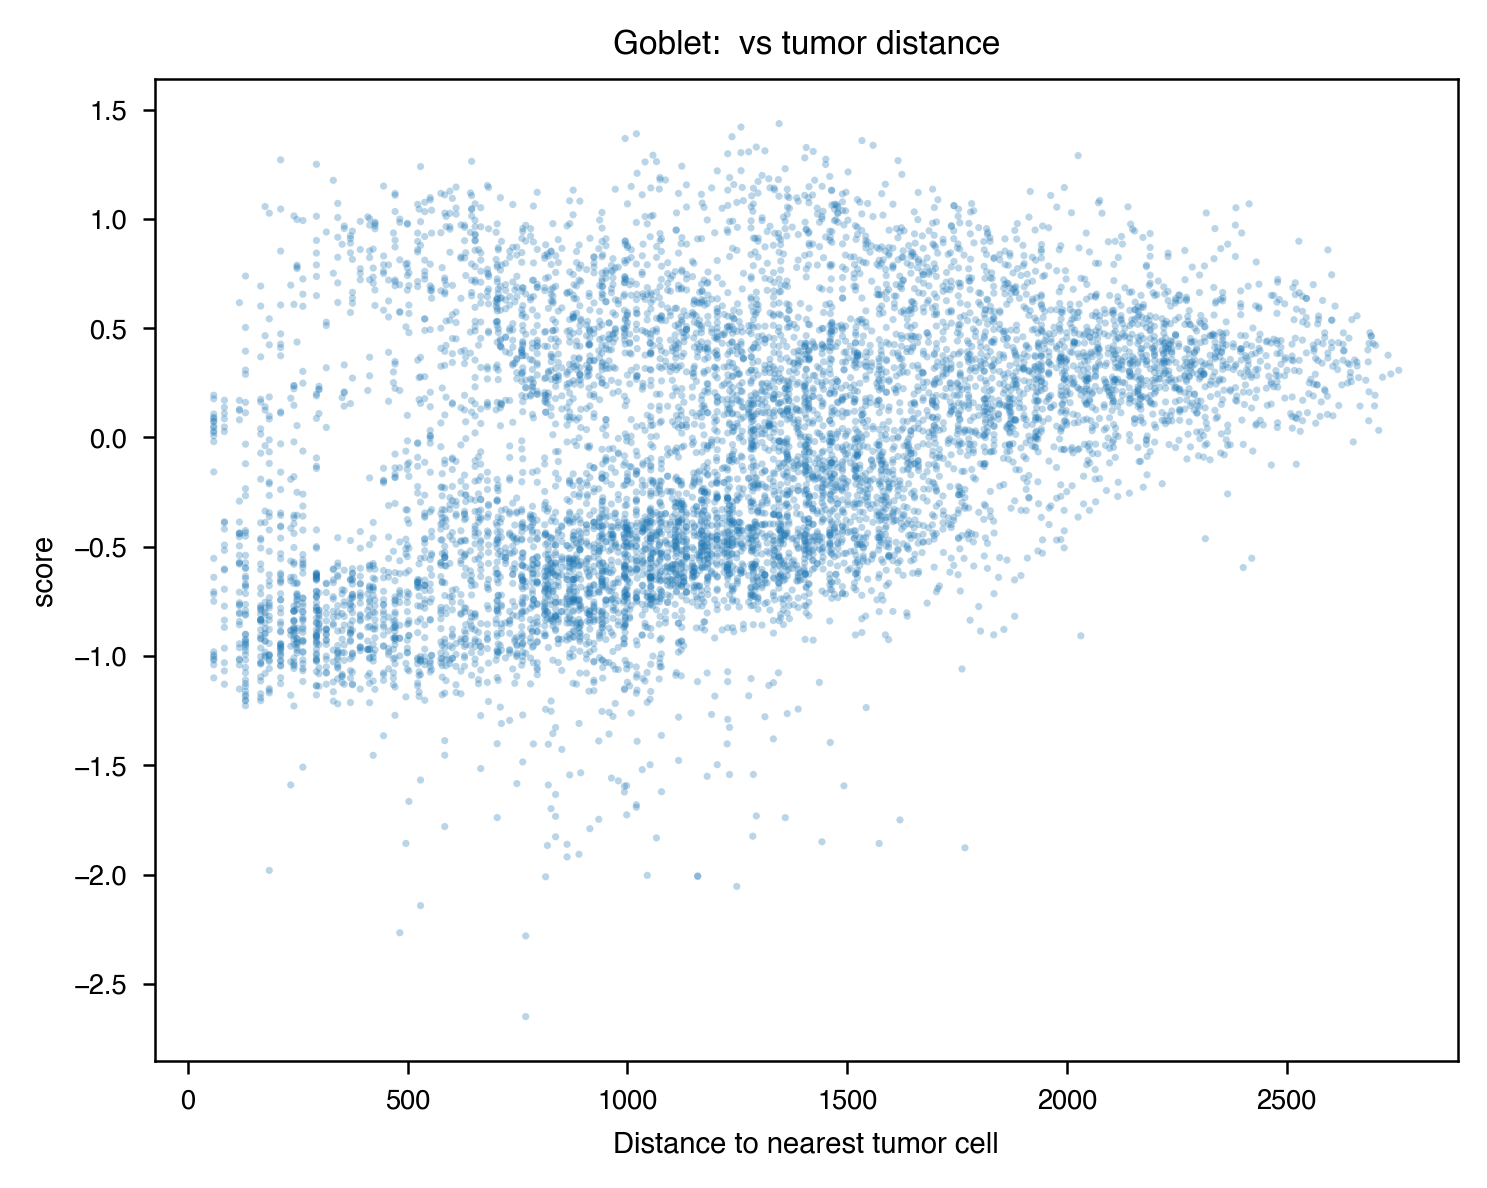

In [36]:
i = 0
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(min_dist_to_tumor, factor_scores_goblet[ct], s=3, alpha=0.3, edgecolors='none')
ax.set_xlabel('Distance to nearest tumor cell')
ax.set_ylabel(f'score')
ax.set_title(f'Goblet:  vs tumor distance')
plt.tight_layout()
plt.show()

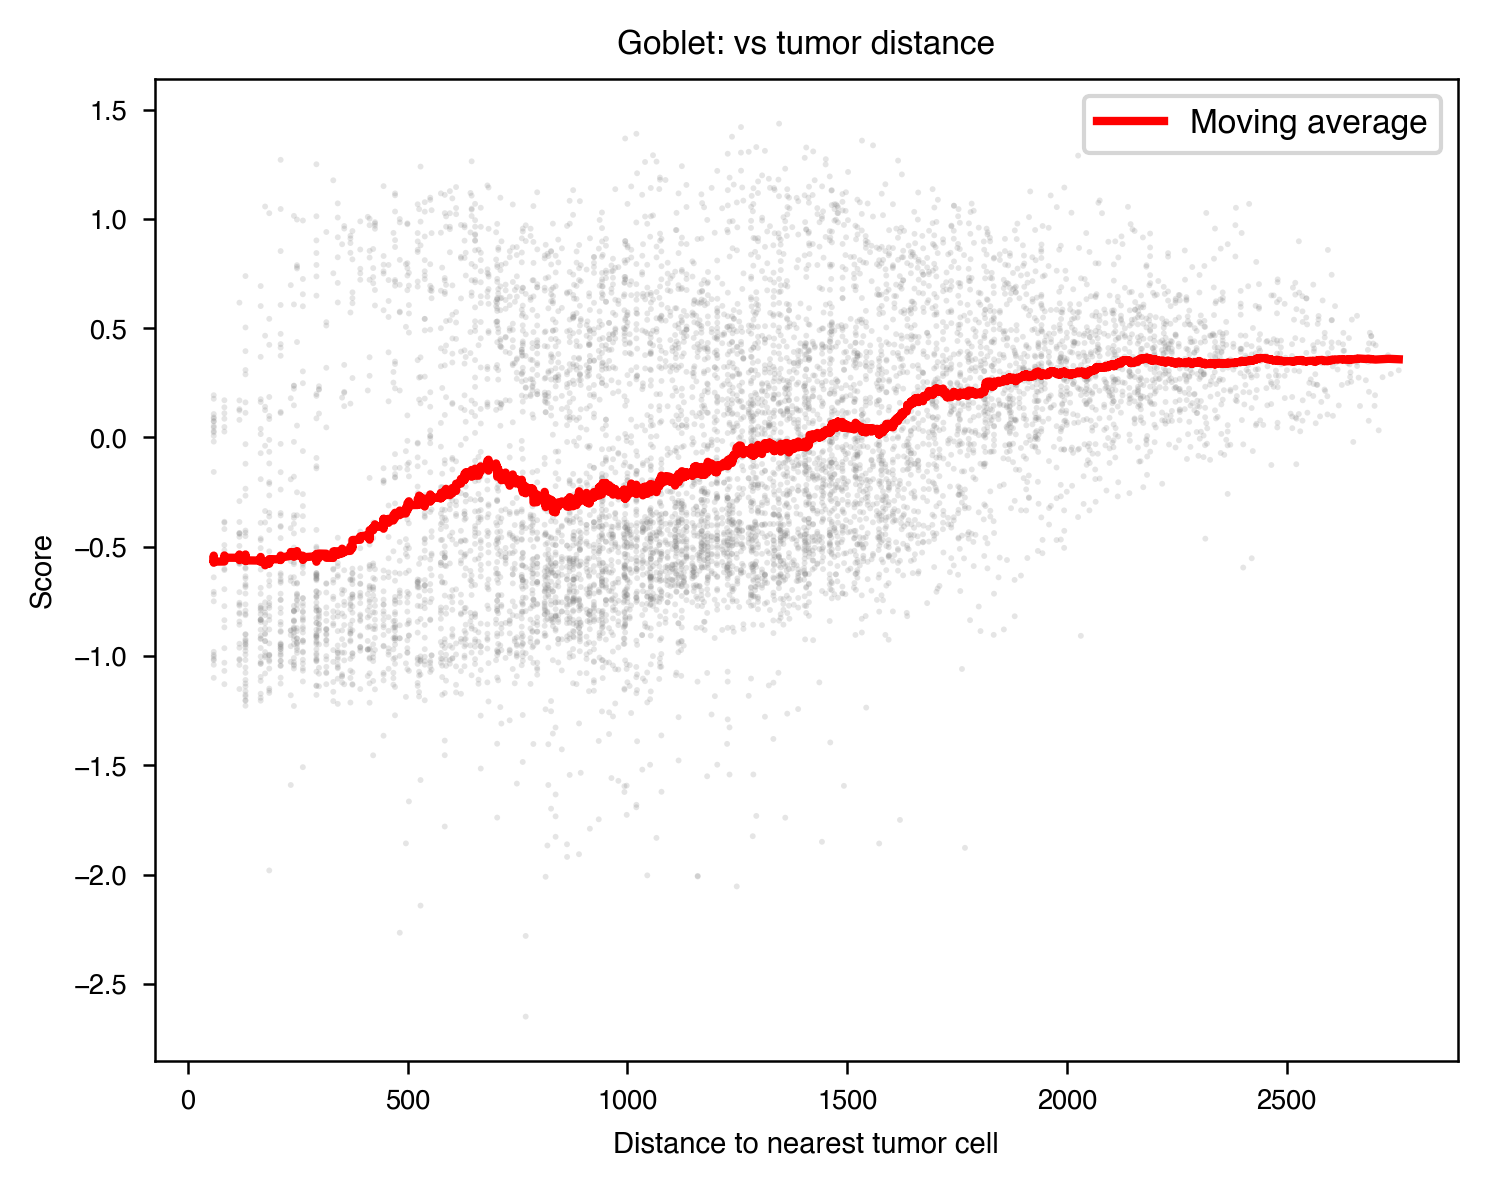

In [37]:
from scipy.ndimage import uniform_filter1d

i = 0
sort_idx = np.argsort(min_dist_to_tumor)
x_sorted = min_dist_to_tumor[sort_idx]
y_sorted = factor_scores_goblet.iloc[sort_idx][ct]

# 滑动平均，window 大小根据数据量调
window = max(len(x_sorted) // 30, 10)
y_smooth = uniform_filter1d(y_sorted.astype(float), size=window)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(min_dist_to_tumor, factor_scores_goblet[ct], s=2, alpha=0.2, c='gray', edgecolors='none')
ax.plot(x_sorted, y_smooth, c='red', lw=2, label='Moving average')
ax.set_xlabel('Distance to nearest tumor cell')
ax.set_ylabel('Score')
ax.set_title('Goblet: vs tumor distance')
ax.legend()
plt.tight_layout()
plt.show()

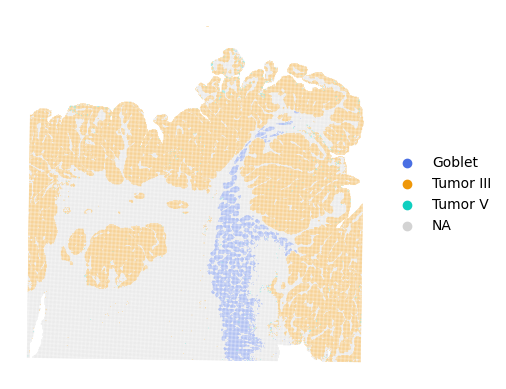

In [ ]:
import scanpy as sc
sc.pl.spatial(sdata_crop1['square_016um'], color = 'cell_type', groups=['Goblet', 'Tumor III', 'Tumor V'],
              spot_size=40, img_key=None, frameon=False, title='',
              #save=os.path.join('CRC_008_celltype.pdf')
              )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap

# %% 1. 准备数据
latent = sdata_crop1['square_016um'].obsm['latent']       # (n_cells, D)
factor_scores = sdata_crop1['square_016um'].obsm['factor']  # (n_cells, K)

print(f"Latent shape: {latent.shape}")
print(f"Factor scores shape: {factor_scores.shape}")

# %% 2. 计算 UMAP
reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, metric='euclidean', random_state=42)
coords = reducer.fit_transform(latent)
sdata_crop1['square_016um'].obsm['X_umap_latent'] = coords
print(f"UMAP done, shape: {coords.shape}")

Latent shape: (137051, 128)
Factor scores shape: (137051, 22)
UMAP done, shape: (137051, 2)


In [188]:
# determine cell type based on max proportion
sdata_crop1['square_016um'].obs['cell_type'] = sdata_crop1['square_016um'].obsm['proportion'].idxmax(axis=1)

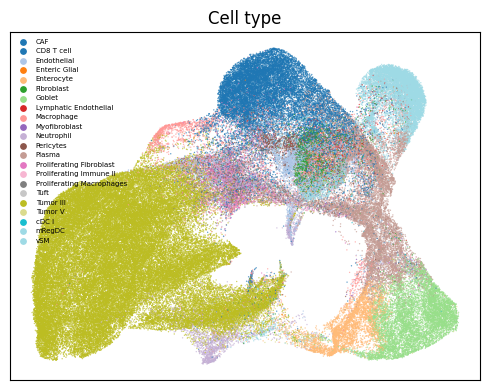

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ct = sdata_crop1['square_016um'].obs['cell_type'].astype('category')
codes = ct.cat.codes.values
cmap_ct = plt.cm.get_cmap('tab20', len(ct.cat.categories))

ax.scatter(coords[:, 0], coords[:, 1], c=codes, cmap=cmap_ct, s=1, alpha=0.7, edgecolors='none')
for i, name in enumerate(ct.cat.categories):
    ax.scatter([], [], c=[cmap_ct(i)], s=15, label=name)
ax.legend(fontsize=5, loc='best', frameon=False)
ax.set_title('Cell type')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

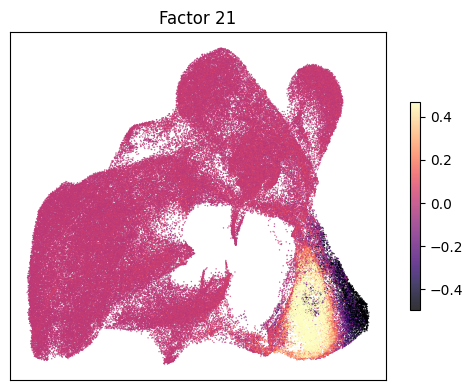

In [ ]:
ct = 'Goblet'  # 改这个数字看不同 factor
scores = factor_scores[ct]
order = np.argsort(scores)

fig, ax = plt.subplots(figsize=(5, 4))
vmin = np.percentile(scores, 2)
vmax = np.percentile(scores, 98)

sc = ax.scatter(
    coords[order, 0], coords[order, 1],
    c=scores[order], cmap='magma',
    vmin=vmin, vmax=vmax,
    s=1, alpha=0.8, edgecolors='none',
)
plt.colorbar(sc, ax=ax, shrink=0.6)
ax.set_title(f'Factor {i}')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


In [ ]:
loading_016[ct].nlargest(10)

ZG16          1.593485
CA2           1.444064
CA1           1.208792
SLC26A2       1.148295
FABP1         1.082849
B3GALT5       1.076560
PADI2         1.029208
ST6GALNAC6    0.816435
MT1X          0.758314
HSD11B2       0.723033
Name: Goblet, dtype: float32

In [ ]:
sdata_crop1['square_016um']

AnnData object with n_obs × n_vars = 137051 × 2780
    obs: 'in_tissue', 'array_row', 'array_col', 'library_size', 'alpha', 'CAF', 'CD8_T_cell', 'Endothelial', 'Enteric_Glial', 'Enterocyte', 'Fibroblast', 'Goblet', 'Lymphatic_Endothelial', 'Macrophage', 'Myofibroblast', 'Neutrophil', 'Pericytes', 'Plasma', 'Proliferating_Fibroblast', 'Proliferating_Immune_II', 'Proliferating_Macrophages', 'Tuft', 'Tumor_III', 'Tumor_V', 'cDC_I', 'mRegDC', 'vSM', 'program_CAF', 'program_CD8_T_cell', 'program_Endothelial', 'program_Enteric_Glial', 'program_Enterocyte', 'program_Fibroblast', 'program_Goblet', 'program_Lymphatic_Endothelial', 'program_Macrophage', 'program_Myofibroblast', 'program_Neutrophil', 'program_Pericytes', 'program_Plasma', 'program_Proliferating_Fibroblast', 'program_Proliferating_Immune_II', 'program_Proliferating_Macrophages', 'program_Tuft', 'program_Tumor_III', 'program_Tumor_V', 'program_cDC_I', 'program_mRegDC', 'program_vSM', 'location_id', 'region', 'temp', 'tmp', 'celltyp

In [ ]:
sdata_crop1['square_016um'].obs['celltype'] = sdata_crop1['square_016um'].obsm['proportion'][ct].apply(lambda x: ct if x>0.1 else 'Other')

In [ ]:
sdata_crop1['square_016um'].obsm['proportion'][sdata_crop1['square_016um'].obsm['proportion'][ct]>0.1][['Tumor III']]

Tumor III    0.569702
dtype: float32

In [ ]:
sdata_crop1['square_016um'].obsm['proportion'][sdata_crop1['square_016um'].obsm['proportion'][ct]>0.1]

,CAF,CD8 T cell,Endothelial,Enteric Glial,Enterocyte,Fibroblast,Goblet,Lymphatic Endothelial,Macrophage,Myofibroblast,...,Plasma,Proliferating Fibroblast,Proliferating Immune II,Proliferating Macrophages,Tuft,Tumor III,Tumor V,cDC I,mRegDC,vSM
s_016um_00061_00268-1,2.370705e-04,2.588180e-03,8.310573e-03,6.906320e-07,0.017466,1.992743e-02,0.194666,6.072394e-07,2.626437e-04,9.913106e-02,...,6.518283e-01,3.502544e-05,1.150121e-06,1.809523e-05,8.996448e-07,5.132236e-06,0.000018,0.000264,3.762778e-08,2.763810e-03
s_016um_00111_00233-1,4.249578e-07,1.660171e-05,6.046595e-05,4.569971e-05,0.000008,1.246017e-05,0.991559,5.656974e-06,1.510424e-06,3.200738e-06,...,8.856501e-07,4.089343e-06,4.885505e-07,1.247834e-07,2.722131e-03,8.559688e-05,0.003888,0.000267,1.380007e-04,5.759665e-06
s_016um_00116_00279-1,3.605903e-09,7.435453e-05,2.297273e-07,3.903636e-07,0.225694,5.202825e-07,0.773734,1.763103e-11,2.353234e-07,2.191753e-07,...,1.981211e-04,1.076644e-09,1.008946e-08,4.583659e-09,2.491129e-04,4.384027e-07,0.000004,0.000018,1.056943e-07,1.334604e-06
s_016um_00043_00286-1,5.347417e-07,7.799197e-05,5.066308e-08,3.287034e-04,0.598453,1.622360e-05,0.359270,3.667920e-10,8.583708e-05,2.137758e-06,...,2.066504e-03,4.528520e-08,3.480308e-07,8.326163e-07,1.450983e-03,2.421901e-05,0.002343,0.000075,4.403274e-05,1.826716e-05
s_016um_00077_00260-1,4.220321e-09,2.371579e-07,1.364031e-08,2.335203e-09,0.000093,7.615071e-08,0.989290,8.304208e-09,8.064531e-08,7.313441e-09,...,1.861628e-07,1.188045e-08,1.284350e-08,1.641477e-09,1.222618e-06,6.705197e-05,0.010538,0.000007,4.956977e-07,7.388099e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_016um_00250_00260-1,5.500075e-07,1.395241e-05,1.476910e-05,6.437719e-05,0.000189,8.215990e-07,0.950743,1.600771e-06,2.958099e-04,4.961531e-07,...,1.015211e-05,6.135918e-09,6.415348e-11,6.054585e-07,1.218067e-02,9.002248e-04,0.031330,0.003393,5.425924e-04,8.401667e-06
s_016um_00140_00321-1,2.180062e-04,1.173953e-05,1.253639e-06,1.772587e-05,0.266311,2.667753e-03,0.330190,1.278201e-09,2.433844e-03,1.344459e-02,...,3.761431e-01,8.729935e-06,3.116489e-07,7.143883e-06,2.757744e-04,1.495918e-06,0.005967,0.001807,3.050821e-05,2.588599e-06
s_016um_00046_00250-1,5.837541e-03,1.678770e-01,1.355577e-04,2.906194e-03,0.000002,1.331247e-01,0.342971,6.983936e-05,1.008685e-03,3.636567e-02,...,2.687761e-02,1.366954e-02,2.148074e-01,1.170148e-02,3.113008e-02,9.695163e-05,0.001683,0.005348,3.891311e-05,3.849141e-04
s_016um_00074_00298-1,2.126395e-06,6.159472e-05,1.340967e-04,5.446981e-05,0.716355,2.183559e-05,0.265169,4.061214e-08,2.626345e-05,7.021519e-06,...,1.593151e-02,7.084088e-07,1.003396e-05,2.392389e-07,1.098101e-04,3.226168e-05,0.001922,0.000053,3.010839e-06,1.283895e-05


(array([ 264.,  194.,  191.,  201.,  181.,  170.,  175.,  153.,  175.,
         152.,  136.,  125.,  133.,  146.,  149.,  142.,  137.,  133.,
         141.,  118.,  141.,  124.,  153.,  152.,  142.,  144.,  134.,
         170.,  151.,  147.,  177.,  153.,  174.,  188.,  162.,  169.,
         193.,  170.,  194.,  205.,  217.,  217.,  236.,  254.,  280.,
         278.,  360.,  373.,  598., 1256.]),
 array([0.10045043, 0.11843943, 0.13642842, 0.15441741, 0.17240641,
        0.1903954 , 0.20838439, 0.22637339, 0.24436238, 0.26235136,
        0.28034037, 0.29832935, 0.31631836, 0.33430734, 0.35229635,
        0.37028533, 0.38827434, 0.40626332, 0.4242523 , 0.44224131,
        0.46023029, 0.4782193 , 0.49620828, 0.51419729, 0.53218627,
        0.55017525, 0.56816429, 0.58615327, 0.60414225, 0.62213123,
        0.64012021, 0.65810925, 0.67609823, 0.69408721, 0.71207619,
        0.73006523, 0.74805421, 0.76604319, 0.78403217, 0.80202115,
        0.82001019, 0.83799917, 0.85598814, 0.87397712, 

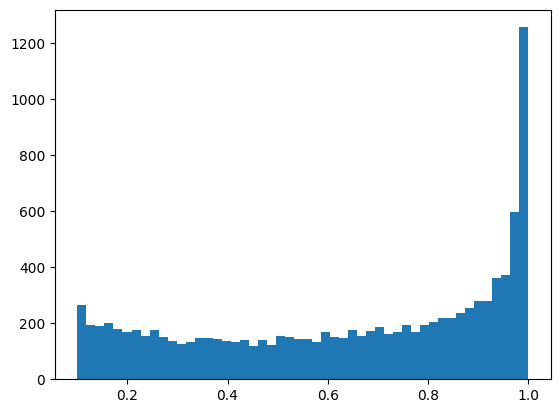

In [ ]:
plt.hist(sdata_crop1['square_016um'].obsm['proportion'][sdata_crop1['square_016um'].obsm['proportion'][ct]>0.1][['Goblet']], bins=50)

In [7]:
adata    = sdata_crop1['square_016um']
adata.obs['cell_type'] = adata.obsm['proportion'].idxmax(axis=1)

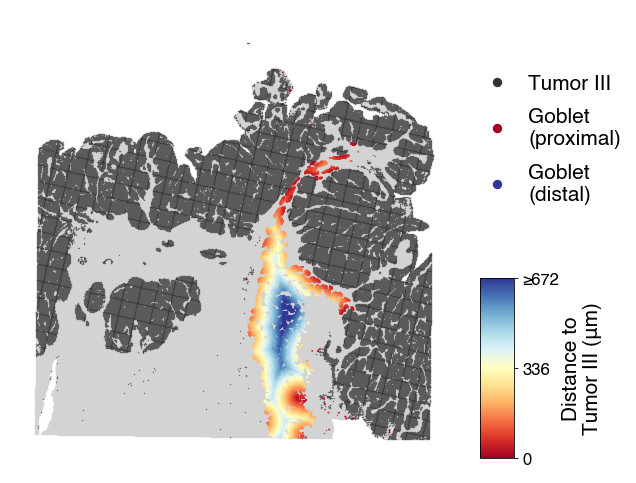

In [10]:

# ============================================================
# 图1：空间地图 — Goblet spots 按距 Tumor III 距离染色
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree

mpl.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

adata    = sdata_crop1['square_016um']
ct       = 'Goblet'
PIXEL_UM = 0.2739   # 16μm / 58.41 px

goblet_mask = (adata.obs['cell_type'] == ct).values
tumor_mask  = (adata.obs['cell_type'] == 'Tumor III').values
goblet_xy   = adata.obsm['spatial'][goblet_mask]
tumor_xy    = adata.obsm['spatial'][tumor_mask]
xy          = adata.obsm['spatial']

# 距离计算
tree = cKDTree(tumor_xy)
min_dist, _ = tree.query(goblet_xy, k=1)
dist_um  = min_dist * PIXEL_UM
dist_cap = np.percentile(dist_um, 98)
cmap_g   = plt.cm.RdYlBu
norm_g   = Normalize(vmin=0, vmax=dist_cap)

# ── 布局 ──
fig = plt.figure(figsize=(3.8, 3.4))
gs  = GridSpec(2, 2,
               width_ratios=[1, 0.22],
               height_ratios=[0.55, 0.45],
               wspace=0.05, hspace=0.0,
               left=0.01, right=0.97, top=0.95, bottom=0.06)

ax_main = fig.add_subplot(gs[:, 0])
ax_leg  = fig.add_subplot(gs[0, 1])
ax_cb   = fig.add_subplot(gs[1, 1])

# ── 主图 ──
ax_main.scatter(xy[:, 0], -xy[:, 1],
                c='lightgray', s=0.5, linewidths=0,
                rasterized=True, zorder=1)
ax_main.scatter(xy[tumor_mask, 0], -xy[tumor_mask, 1],
                c='#333333', s=0.5, linewidths=0, alpha=0.6,
                rasterized=True, zorder=2)
ax_main.scatter(goblet_xy[:, 0], -goblet_xy[:, 1],
                c=dist_um, cmap=cmap_g, norm=norm_g,
                s=1.0, linewidths=0, rasterized=True, zorder=3)

ax_main.set_aspect('equal', adjustable='box')
ax_main.set_xticks([]); ax_main.set_yticks([])
for sp in ax_main.spines.values():
    sp.set_visible(False)

# ── legend ──
legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='#333333', markersize=4.5,
           label='Tumor III', markeredgewidth=0),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=cmap_g(norm_g(0)), markersize=4.5,
           label='Goblet\n(proximal)', markeredgewidth=0),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=cmap_g(norm_g(dist_cap)), markersize=4.5,
           label='Goblet\n(distal)', markeredgewidth=0),
]
ax_leg.legend(handles=legend_elements,
              loc='center left', fontsize=10,
              frameon=False, handletextpad=0.5,
              labelspacing=0.7, borderpad=0)
ax_leg.axis('off')

# ── colorbar（用 inset_axes 控制宽度）──
ax_cb.axis('off')
# [left, bottom, width, height]，width=0.35 使 colorbar 更窄
cax = ax_cb.inset_axes([0.15, 0.05, 0.35, 0.88])
cb = ColorbarBase(cax, cmap=cmap_g, norm=norm_g, orientation='vertical')
cb.set_label('Distance to\nTumor III (μm)', fontsize=10, labelpad=1.5,
             linespacing=1.1)
ticks = [0, dist_cap * 0.5, dist_cap]
cb.set_ticks(ticks)
cb.set_ticklabels([f'{t:.0f}' for t in ticks[:-1]] + [f'≥{dist_cap:.0f}'])
cb.ax.tick_params(labelsize=8, length=2, width=0.4, pad=2)
cb.outline.set_linewidth(0.4)
plt.tight_layout()
plt.savefig('goblet_spatial_distance.jpg', dpi=600,
            bbox_inches='tight', 
            transparent=True)
plt.savefig('goblet_spatial_distance.pdf', dpi=600,
            bbox_inches='tight',
            transparent=True)
plt.show()


In [12]:
linregress(x, y)

LinregressResult(slope=-0.001618813993454626, intercept=0.6206424188886286, rvalue=-0.3886192011989424, pvalue=3.6323735889579477e-271, stderr=4.413981989016918e-05, intercept_stderr=0.015638324962879507)

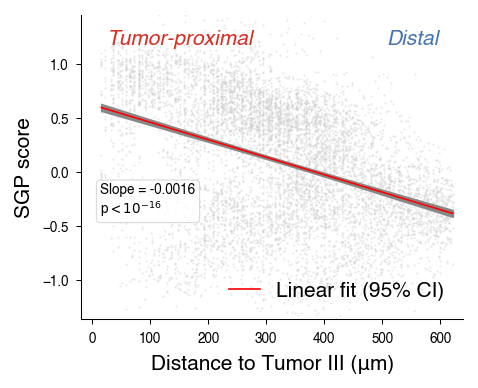

In [ ]:

# ============================================================
# 图2：SGP score vs. 距 Tumor III 距离（均值 ± 95% CI + 滑动平均）
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree

mpl.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

adata    = sdata_crop1['square_016um']
ct       = 'Goblet'
PIXEL_UM = 0.2739   # 16μm / 58.41 px

goblet_mask = (adata.obs['cell_type'] == ct).values
tumor_mask  = (adata.obs['cell_type'] == 'Tumor III').values
goblet_xy   = adata.obsm['spatial'][goblet_mask]
tumor_xy    = adata.obsm['spatial'][tumor_mask]

# 距离计算（cKDTree，远快于 cdist）
tree = cKDTree(tumor_xy)
min_dist_px, _ = tree.query(goblet_xy, k=1)
dist_um = min_dist_px * PIXEL_UM

program_score = -adata.obsm['factor'][ct].values[goblet_mask]

# 截断至 95th percentile，去掉长尾
dist_cap = np.percentile(dist_um, 95)
mask_use = dist_um <= dist_cap
x = dist_um[mask_use]
y = program_score[mask_use]

# ── 线性拟合 + 系数 95% CI ──
from scipy.stats import linregress, t as t_dist
slope, intercept, r_value, p_lm, se_slope = linregress(x, y)
x_fit  = np.linspace(x.min(), x.max(), 300)
y_fit  = slope * x_fit + intercept
y_pred = slope * x + intercept
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2_val = 1 - ss_res / ss_tot
n      = len(x)
Sxx    = np.sum((x - x.mean()) ** 2)
s_err  = np.sqrt(ss_res / (n - 2))
se_int = s_err * np.sqrt(np.sum(x**2) / (n * Sxx))
t_crit = t_dist.ppf(0.975, df=n - 2)
slope_ci = (slope - t_crit * se_slope, slope + t_crit * se_slope)
int_ci   = (intercept - t_crit * se_int,  intercept + t_crit * se_int)


# ── 绘图 ──
fig, ax = plt.subplots(figsize=(3.2, 2.6))

# 背景散点（降采样 2000 点）
rng     = np.random.default_rng(42)
subsamp = rng.choice(len(x), size=len(x), replace=False)
ax.scatter(x[subsamp], y[subsamp],
           c='#D0D0D0', s=1.0, linewidths=0, alpha=0.5,
           rasterized=True, zorder=1)

# # slope CI 扇形（以均值点为轴心）
# y_mean_pt = slope * x.mean() + intercept
# y_lo_fan  = y_mean_pt + slope_ci[0] * (x_fit - x.mean())
# y_hi_fan  = y_mean_pt + slope_ci[1] * (x_fit - x.mean())
# ax.fill_between(x_fit, y_lo_fan, y_hi_fan,
#                 color='#888888', alpha=0.5, linewidth=0, zorder=2)
# # 线性拟合
# ax.plot(x_fit, y_fit,
#         color='#888888', lw=1.2, zorder=3, label='Linear fit')
# ── 回归均值响应 95% CI（含截距+斜率联合不确定性）──
se_mean  = s_err * np.sqrt(1.0/n + (x_fit - x.mean())**2 / Sxx)
y_lo_ci  = y_fit - t_crit * se_mean
y_hi_ci  = y_fit + t_crit * se_mean

ax.fill_between(x_fit, y_lo_ci, y_hi_ci,
                color='#888888', alpha=1, linewidth=1, zorder=2)
ax.plot(x_fit, y_fit,
        color='Red', lw=0.8, zorder=3, label='Linear fit (95% CI)')

# 轴格式
ax.set_xlabel('Distance to Tumor III (μm)', fontsize=10)
ax.set_ylabel('SGP score', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=6.5)
ax.set_xlim(-dist_cap * 0.03, dist_cap * 1.03)
y_lo  = np.percentile(y, 2)
y_hi  = np.percentile(y, 98)                                                                                                                                                                                                                                                                                            
y_pad = (y_hi - y_lo) * 0.15
ax.set_ylim(y_lo - y_pad, y_hi + y_pad)  
# 相关系数
# 标注
p_str = f"p = {p_lm:.2e}" if p_lm >= 1e-16 else "p < $10^{-16}$"
annot = f"Slope = {slope:.4f}\n{p_str}"
ax.text(0.05, 0.450, annot,
        transform=ax.transAxes, fontsize=6.5,
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="#CCCCCC", linewidth=0.5, alpha=0.8))
slope_per100 = slope * 100
ci_lo_100, ci_hi_100 = slope_ci[0]*100, slope_ci[1]*100

# p 值格式化
# if p_lm < 1e-3:
#     p_str = f"{p_lm:.1e}".replace("e-0", "e-").replace("e+0", "e+")
#     p_str = f"$p = {p_str.split('e')[0]} \\times 10^{{{int(p_str.split('e')[1])}}}$"
# else:
#     p_str = f"p = {p_lm:.3f}"

# annot = (f"Slope = {slope_per100:.3f} per 100 μm\n"
#          f"95% CI [{ci_lo_100:.3f}, {ci_hi_100:.3f}]\n"
#          f"$R^2$ = {r2_val:.3f},  {p_str}\n"
#          f"n = {n:,} spots")

# ax.text(0.05, 0.450, annot,
#         transform=ax.transAxes, fontsize=6.5,
#         ha="left", va="top",
#         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
#                   edgecolor="#CCCCCC", linewidth=0.5, alpha=0.85))
# 方向标注
ymin, ymax = ax.get_ylim()
dy = ymax - ymin
ax.text(dist_cap * 0.04, ymax - dy * 0.05,
        'Tumor-proximal', fontsize=10, color='#D73027',
        ha='left', va='top', fontstyle='italic')
ax.text(dist_cap * 0.96, ymax - dy * 0.05,
        'Distal', fontsize=10, color='#4575B4',
        ha='right', va='top', fontstyle='italic')

# 图例
legend_elements = [
    Line2D([0], [0], color='Red', lw=0.8, label='Linear fit (95% CI)'),
]
ax.legend(handles=legend_elements, fontsize=10, frameon=False,
          loc='lower right', handlelength=1.5)

plt.tight_layout()
plt.savefig('goblet_distance_lineplot.pdf', dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()

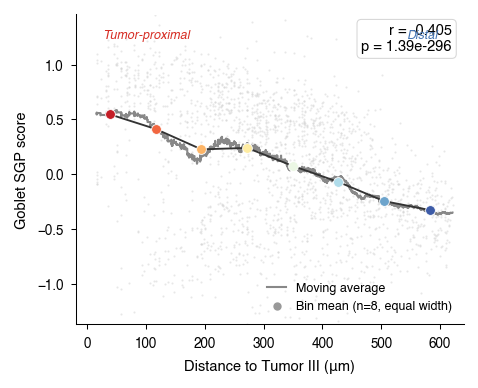

In [20]:

# ============================================================
# 图2（原版）：SGP score vs. 距 Tumor III 距离
#   滑动平均 + bin mean 彩色点 + Spearman r
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
from scipy.ndimage import uniform_filter1d
from scipy.stats import spearmanr

mpl.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

adata    = sdata_crop1['square_016um']
ct       = 'Goblet'
PIXEL_UM = 0.2739

goblet_mask = (adata.obs['cell_type'] == ct).values
tumor_mask  = (adata.obs['cell_type'] == 'Tumor III').values
goblet_xy   = adata.obsm['spatial'][goblet_mask]
tumor_xy    = adata.obsm['spatial'][tumor_mask]

tree = cKDTree(tumor_xy)
min_dist_px, _ = tree.query(goblet_xy, k=1)
dist_um = min_dist_px * PIXEL_UM

program_score = -adata.obsm['factor'][ct].values[goblet_mask]

dist_cap = np.percentile(dist_um, 95)
mask_use = dist_um <= dist_cap
x = dist_um[mask_use]
y = program_score[mask_use]

# ── 滑动平均 ──
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]
window   = max(len(x_sorted) // 30, 10)
y_smooth = uniform_filter1d(y_sorted.astype(float), size=window)

# ── 8 个等宽 bin，只取均值 ──
N_BINS    = 8
bin_edges = np.linspace(0, dist_cap, N_BINS + 1)
bin_mids  = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_means = []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    vals = y[(x >= lo) & (x < hi)]
    bin_means.append(vals.mean() if len(vals) >= 5 else np.nan)
bin_means = np.array(bin_means)
valid     = ~np.isnan(bin_means)

cmap_line  = plt.cm.RdYlBu
norm_line  = mpl.colors.Normalize(vmin=0, vmax=dist_cap)
bin_colors = [cmap_line(norm_line(m)) for m in bin_mids]

# ── 绘图 ──
fig, ax = plt.subplots(figsize=(3.2, 2.6))

# 背景散点（降采样 2000 点）
rng     = np.random.default_rng(42)
subsamp = rng.choice(len(x), size=min(2000, len(x)), replace=False)
ax.scatter(x[subsamp], y[subsamp],
           c='#D0D0D0', s=1.0, linewidths=0, alpha=0.5,
           rasterized=True, zorder=1)

# 滑动平均
ax.plot(x_sorted, y_smooth,
        color='#888888', lw=1.0, zorder=2, label='Moving average')

# bin 均值连线
ax.plot(bin_mids[valid], bin_means[valid],
        color='#333333', lw=0.9, zorder=2)

# bin 均值彩色点（RdYlBu，与空间图一致）
for mid, mean, col in zip(bin_mids[valid], bin_means[valid],
                           [bin_colors[i] for i, v in enumerate(valid) if v]):
    ax.scatter(mid, mean, color=col, s=22,
               edgecolors='white', linewidths=0.4, zorder=3)

# 轴格式
ax.set_xlabel('Distance to Tumor III (μm)', fontsize=7)
ax.set_ylabel('Goblet SGP score', fontsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=6.5)
ax.set_xlim(-dist_cap * 0.03, dist_cap * 1.03)
y_lo  = np.percentile(y, 2)
y_hi  = np.percentile(y, 98)
y_pad = (y_hi - y_lo) * 0.15
ax.set_ylim(y_lo - y_pad, y_hi + y_pad)

# Spearman r + p
r_val, p_val = spearmanr(x, y)
ax.text(0.97, 0.97,
        f"r = {r_val:.3f}\np = {p_val:.2e}",
        transform=ax.transAxes, fontsize=7,
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#CCCCCC', linewidth=0.5, alpha=0.8))

# 方向标注
ymin, ymax = ax.get_ylim()
dy = ymax - ymin
ax.text(dist_cap * 0.04, ymax - dy * 0.05,
        'Tumor-proximal', fontsize=6, color='#D73027',
        ha='left', va='top', fontstyle='italic')
ax.text(dist_cap * 0.96, ymax - dy * 0.05,
        'Distal', fontsize=6, color='#4575B4',
        ha='right', va='top', fontstyle='italic')

# 图例
legend_elements = [
    Line2D([0], [0], color='#888888', lw=1.0, label='Moving average'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#999999', markersize=4,
           label=f'Bin mean (n={N_BINS}, equal width)', markeredgewidth=0),
]
ax.legend(handles=legend_elements, fontsize=6, frameon=False,
          loc='lower right', handlelength=1.5)

plt.tight_layout()
plt.savefig('goblet_distance_lineplot_orig.pdf', dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()


In [27]:
window

252

In [12]:

# ============================================================
# 图3：Goblet factor score 空间分布 — Visium HD + Xenium（HE 背景）
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colorbar import ColorbarBase

mpl.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 7,
    'axes.linewidth': 0.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

ct          = 'Goblet'
prop_thresh = 0.1

# ──────────────────────────────────────────────────────────
# Visium HD
# ──────────────────────────────────────────────────────────
adata_hd  = sdata_crop1['square_016um']
hd_xy     = adata_hd.obsm['spatial']
hd_score  = adata_hd.obsm['factor'][ct].values
hd_mask   = adata_hd.obsm['proportion'][ct].values > prop_thresh

# HE 图像：从 SpatialData 提取（multiscale DataArray，dims = c,y,x）
img_da_hd = sdata_crop1['Visium_HD_Human_Colon_Cancer_P2_hires_image']
# 取最低分辨率层（level=-1）以节省内存；若想更清晰可改为 [0]
img_np_hd = np.array(img_da_hd)      # (C, Y, X)
if img_np_hd.ndim == 3 and img_np_hd.shape[0] in (1, 3, 4):
    img_np_hd = np.moveaxis(img_np_hd, 0, -1)   # → (Y, X, C)
if img_np_hd.max() > 1:
    img_np_hd = (img_np_hd / 255.0).clip(0, 1).astype(np.float32)

# 用 DataArray 的坐标轴确定图像在 spot 坐标系下的 extent
# scatter 用 (x, -y)，image extent 也对应翻转 y
if 'y' in img_da_hd.dims:
    y_c = img_da_hd.coords['y'].values
    x_c = img_da_hd.coords['x'].values
    extent_hd = [float(x_c.min()), float(x_c.max()),
                 -float(y_c.max()), -float(y_c.min())]
else:
    # fallback：用 spot 坐标范围撑满
    extent_hd = [hd_xy[:,0].min(), hd_xy[:,0].max(),
                 -hd_xy[:,1].max(), -hd_xy[:,1].min()]

# ──────────────────────────────────────────────────────────
# Xenium
# ──────────────────────────────────────────────────────────
xe_xy    = adata_xenium.obsm['spatial']
xe_score = adata_xenium.obsm['factor'][ct].values
xe_mask  = adata_xenium.obsm['proportion'][ct].values > prop_thresh

# HE 图像：从 adata_xenium.uns['spatial'] 获取
lib_id   = list(adata_xenium.uns['spatial'].keys())[0]
img_xe   = adata_xenium.uns['spatial'][lib_id]['images']['hires'].copy()  # (H, W, 3)
scalef   = adata_xenium.uns['spatial'][lib_id]['scalefactors']['tissue_hires_scalef']
if img_xe.max() > 1:
    img_xe = (img_xe / 255.0).clip(0, 1).astype(np.float32)
H_xe, W_xe = img_xe.shape[:2]

# 现有 Xenium scatter 用 (-x, -y)：
#   col j → scatter_x = -(j / scalef)  →  需水平翻转图像
#   row i → scatter_y = -(i / scalef)
img_xe_flip = img_xe[:, ::-1, :]        # 水平翻转
extent_xe   = [-W_xe / scalef, 0.0, -H_xe / scalef, 0.0]

# ──────────────────────────────────────────────────────────
# 共用 colormap（与 cell 80e8d5f2 一致：bwr + TwoSlopeNorm）
# ──────────────────────────────────────────────────────────
all_fg = np.concatenate([hd_score[hd_mask], xe_score[xe_mask]])
v_abs  = max(abs(np.percentile(all_fg, 1)), abs(np.percentile(all_fg, 99)))
norm_f = TwoSlopeNorm(vcenter=0, vmin=-v_abs, vmax=v_abs)
cmap_f = plt.cm.bwr

# ──────────────────────────────────────────────────────────
# 布局
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(8.0, 3.6),
    gridspec_kw={'width_ratios': [1, 1, 0.06], 'wspace': 0.05})
ax_hd, ax_xe, ax_cb = axes

for ax in (ax_hd, ax_xe):
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

# ── Visium HD ──
ax_hd.imshow(img_np_hd, extent=extent_hd, origin='upper',
             aspect='equal', zorder=0)
ax_hd.scatter(hd_xy[:, 0], -hd_xy[:, 1],
              c='lightgray', s=0.5, linewidths=0, alpha=0.3,
              rasterized=True, zorder=1)
ax_hd.scatter(hd_xy[hd_mask, 0], -hd_xy[hd_mask, 1],
              c=hd_score[hd_mask], cmap=cmap_f, norm=norm_f,
              s=1.5, linewidths=0, rasterized=True, zorder=2)
ax_hd.set_aspect('equal', adjustable='box')
ax_hd.set_title('Visium HD (16 μm)', fontsize=7, pad=3)

# ── Xenium ──
ax_xe.imshow(img_xe_flip, extent=extent_xe, origin='upper',
             aspect='equal', zorder=0)
ax_xe.scatter(-xe_xy[:, 0], -xe_xy[:, 1],
              c='lightgray', s=0.3, linewidths=0, alpha=0.3,
              rasterized=True, zorder=1)
ax_xe.scatter(-xe_xy[xe_mask, 0], -xe_xy[xe_mask, 1],
              c=xe_score[xe_mask], cmap=cmap_f, norm=norm_f,
              s=1.5, linewidths=0, rasterized=True, zorder=2)
ax_xe.set_aspect('equal', adjustable='box')
ax_xe.set_title('Xenium', fontsize=7, pad=3)

# ── Colorbar ──
ax_cb.axis('off')
cax = ax_cb.inset_axes([0.1, 0.05, 0.6, 0.88])
cb  = ColorbarBase(cax, cmap=cmap_f, norm=norm_f, orientation='vertical')
cb.set_label(f'{ct} SGP score', fontsize=6, labelpad=3, linespacing=1.1)
cb.set_ticks([-v_abs, 0, v_abs])
cb.set_ticklabels([f'{-v_abs:.2f}', '0', f'{v_abs:.2f}'])
cb.ax.tick_params(labelsize=5.5, length=2, width=0.4, pad=2)
cb.outline.set_linewidth(0.4)

plt.savefig('goblet_factor_spatial_comparison.pdf', dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()


NameError: name 'adata_xenium' is not defined

In [ ]:

import json, os

adata = sdata_crop1['square_016um']

# 方法1：看 uns['spatial'] 里的 scalefactors
print("=== uns['spatial'] keys ===")
if 'spatial' in adata.uns:
    for k, v in adata.uns['spatial'].items():
        print(k, type(v))
        if isinstance(v, dict):
            for kk, vv in v.items():
                print(f"  {kk}: {vv}")


In [38]:

# 方法2：从相邻 spot 的坐标差推算像素间距
# 16μm bin 中，array_col 相差 1 的相邻 spot，物理距离应为 16μm
import numpy as np

adata = sdata_crop1['square_016um']
xy  = adata.obsm['spatial']
col = adata.obs['array_col'].values
row = adata.obs['array_row'].values

# 找 array_row 相同、array_col 相差 1 的 spot 对
same_row = row == row[0]
sub_col  = col[same_row]
sub_xy   = xy[same_row]
sort_idx = np.argsort(sub_col)
sub_col  = sub_col[sort_idx]
sub_xy   = sub_xy[sort_idx]

diffs = np.diff(sub_xy[sub_col[:-1] + 1 == sub_col[1:]], axis=0)
pixel_spacing = np.linalg.norm(diffs, axis=1).mean()

print(f"Pixel spacing between adjacent 16μm bins: {pixel_spacing:.3f} px")
print(f"=> 1 pixel = {16 / pixel_spacing:.4f} μm")
print(f"=> 1 μm    = {pixel_spacing / 16:.4f} px")


IndexError: boolean index did not match indexed array along dimension 0; dimension is 411 but corresponding boolean dimension is 410

In [39]:

import numpy as np

adata = sdata_crop1['square_016um']
xy  = adata.obsm['spatial']
col = adata.obs['array_col'].values
row = adata.obs['array_row'].values

# 找 array_row 相同的一组 spots，按 array_col 排序
target_row = row[0]
mask = row == target_row
sub_col = col[mask]
sub_xy  = xy[mask]

sort_idx = np.argsort(sub_col)
sub_col  = sub_col[sort_idx]
sub_xy   = sub_xy[sort_idx]

# 找 array_col 连续相差 1 的 spot 对
adj = sub_col[:-1] + 1 == sub_col[1:]
pixel_spacings = np.linalg.norm(sub_xy[1:][adj] - sub_xy[:-1][adj], axis=1)

print(f"Adjacent spot pixel spacings (sample): {pixel_spacings[:5].round(3)}")
print(f"Mean pixel spacing: {pixel_spacings.mean():.3f} px")
print(f"=> 1 pixel = {16 / pixel_spacings.mean():.4f} μm")


Adjacent spot pixel spacings (sample): [58.403 58.403 58.403 58.404 58.404]
Mean pixel spacing: 58.414 px
=> 1 pixel = 0.2739 μm
